In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
import matplotlib.pyplot as plt

### Single Layer Perceptron for AND Gate

We will implement a single-layer perceptron to learn the AND logic gate. The AND gate outputs `1` only if both inputs are `1`, otherwise `0`.

In [2]:
# Input data for AND gate
X_and = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float32)
y_and = np.array([[0], [0], [0], [1]], dtype=np.float32)

# Build the Perceptron model
model_and = Sequential([
    Dense(1, activation='sigmoid', input_shape=(2,))
])

# Compile the model
# 'sgd' optimizer (Stochastic Gradient Descent)
# 'mse' (Mean Squared Error) or 'binary_crossentropy' for binary classification
model_and.compile(optimizer=SGD(learning_rate=0.1), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
print("\nTraining Perceptron for AND Gate...")
history_and = model_and.fit(X_and, y_and, epochs=2000, verbose=0)

# Evaluate the model
loss_and, accuracy_and = model_and.evaluate(X_and, y_and)
print(f"AND Gate - Final Loss: {loss_and:.4f}, Accuracy: {accuracy_and:.4f}")

# Make predictions
predictions_and = (model_and.predict(X_and) > 0.5).astype(int)
print("\nAND Gate Predictions:")
for i in range(len(X_and)):
    print(f"Input: {X_and[i]} -> Predicted Output: {predictions_and[i][0]} (Actual: {y_and[i][0]})")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training Perceptron for AND Gate...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - accuracy: 1.0000 - loss: 0.0814
AND Gate - Final Loss: 0.0814, Accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step

AND Gate Predictions:
Input: [0. 0.] -> Predicted Output: 0 (Actual: 0.0)
Input: [0. 1.] -> Predicted Output: 0 (Actual: 0.0)
Input: [1. 0.] -> Predicted Output: 0 (Actual: 0.0)
Input: [1. 1.] -> Predicted Output: 1 (Actual: 1.0)


#### Plotting the Decision Boundary for AND Gate

Since the AND gate has two inputs, we can visualize its decision boundary in a 2D plot. The perceptron will draw a line that separates the inputs resulting in `0` from those resulting in `1`.

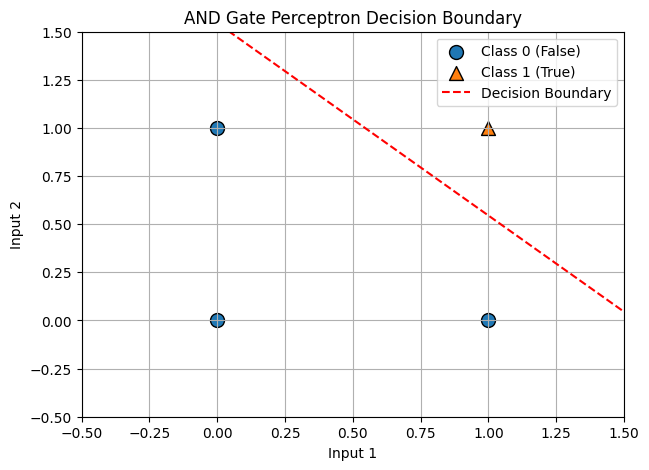

In [3]:
# Plotting the decision boundary for AND gate
plt.figure(figsize=(7, 5))

# Plot data points
plt.scatter(X_and[y_and.flatten() == 0, 0], X_and[y_and.flatten() == 0, 1], s=100, edgecolors='k', marker='o', label='Class 0 (False)')
plt.scatter(X_and[y_and.flatten() == 1, 0], X_and[y_and.flatten() == 1, 1], s=100, edgecolors='k', marker='^', label='Class 1 (True)')

# Plot the decision boundary
weights_and = model_and.get_weights()[0]
bias_and = model_and.get_weights()[1]

# Decision boundary is w1*x1 + w2*x2 + b = 0 (for sigmoid, this is the point of 0.5 probability)
x_vals = np.linspace(-0.5, 1.5, 100) # Range for plotting
y_vals = (-weights_and[0] * x_vals - bias_and) / weights_and[1]

plt.plot(x_vals, y_vals, 'r--', label='Decision Boundary')

plt.title('AND Gate Perceptron Decision Boundary')
plt.xlabel('Input 1')
plt.ylabel('Input 2')
plt.xlim([-0.5, 1.5])
plt.ylim([-0.5, 1.5])
plt.grid(True)
plt.legend()
plt.show()


### Single Layer Perceptron for OR Gate

Now, let's implement a single-layer perceptron for the OR logic gate. The OR gate outputs `1` if at least one of its inputs is `1`, otherwise `0`.

In [4]:
# Input data for OR gate
X_or = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float32)
y_or = np.array([[0], [1], [1], [1]], dtype=np.float32)

# Build the Perceptron model
model_or = Sequential([
    Dense(1, activation='sigmoid', input_shape=(2,))
])

# Compile the model
model_or.compile(optimizer=SGD(learning_rate=0.1), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
print("\nTraining Perceptron for OR Gate...")
history_or = model_or.fit(X_or, y_or, epochs=2000, verbose=0)

# Evaluate the model
loss_or, accuracy_or = model_or.evaluate(X_or, y_or)
print(f"OR Gate - Final Loss: {loss_or:.4f}, Accuracy: {accuracy_or:.4f}")

# Make predictions
predictions_or = (model_or.predict(X_or) > 0.5).astype(int)
print("\nOR Gate Predictions:")
for i in range(len(X_or)):
    print(f"Input: {X_or[i]} -> Predicted Output: {predictions_or[i][0]} (Actual: {y_or[i][0]})")


Training Perceptron for OR Gate...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step - accuracy: 1.0000 - loss: 0.0478
OR Gate - Final Loss: 0.0478, Accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step

OR Gate Predictions:
Input: [0. 0.] -> Predicted Output: 0 (Actual: 0.0)
Input: [0. 1.] -> Predicted Output: 1 (Actual: 1.0)
Input: [1. 0.] -> Predicted Output: 1 (Actual: 1.0)
Input: [1. 1.] -> Predicted Output: 1 (Actual: 1.0)


#### Plotting the Decision Boundary for OR Gate

Similar to the AND gate, we can visualize the decision boundary for the OR gate. The perceptron will draw a line that separates the inputs resulting in `0` from those resulting in `1`.

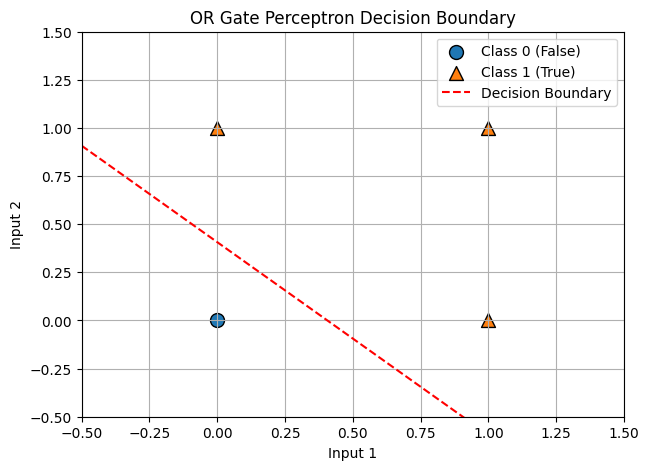

In [5]:
# Plotting the decision boundary for OR gate
plt.figure(figsize=(7, 5))

# Plot data points
plt.scatter(X_or[y_or.flatten() == 0, 0], X_or[y_or.flatten() == 0, 1], s=100, edgecolors='k', marker='o', label='Class 0 (False)')
plt.scatter(X_or[y_or.flatten() == 1, 0], X_or[y_or.flatten() == 1, 1], s=100, edgecolors='k', marker='^', label='Class 1 (True)')

# Plot the decision boundary
weights_or = model_or.get_weights()[0]
bias_or = model_or.get_weights()[1]

x_vals = np.linspace(-0.5, 1.5, 100)
y_vals = (-weights_or[0] * x_vals - bias_or) / weights_or[1]

plt.plot(x_vals, y_vals, 'r--', label='Decision Boundary')

plt.title('OR Gate Perceptron Decision Boundary')
plt.xlabel('Input 1')
plt.ylabel('Input 2')
plt.xlim([-0.5, 1.5])
plt.ylim([-0.5, 1.5])
plt.grid(True)
plt.legend()
plt.show()

### Single Layer Perceptron for NOT Gate

Finally, we will implement a single-layer perceptron for the NOT logic gate. The NOT gate takes a single input and inverts it (e.g., `0` becomes `1`, and `1` becomes `0`).

In [6]:
# Input data for NOT gate
X_not = np.array([[0], [1]], dtype=np.float32)
y_not = np.array([[1], [0]], dtype=np.float32)

# Build the Perceptron model (1 input, 1 output)
model_not = Sequential([
    Dense(1, activation='sigmoid', input_shape=(1,))
])

# Compile the model
model_not.compile(optimizer=SGD(learning_rate=0.1), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
print("\nTraining Perceptron for NOT Gate...")
history_not = model_not.fit(X_not, y_not, epochs=2000, verbose=0)

# Evaluate the model
loss_not, accuracy_not = model_not.evaluate(X_not, y_not)
print(f"NOT Gate - Final Loss: {loss_not:.4f}, Accuracy: {accuracy_not:.4f}")

# Make predictions
predictions_not = (model_not.predict(X_not) > 0.5).astype(int)
print("\nNOT Gate Predictions:")
for i in range(len(X_not)):
    print(f"Input: {X_not[i][0]} -> Predicted Output: {predictions_not[i][0]} (Actual: {y_not[i][0]})")


Training Perceptron for NOT Gate...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 1.0000 - loss: 0.0260
NOT Gate - Final Loss: 0.0260, Accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step

NOT Gate Predictions:
Input: 0.0 -> Predicted Output: 1 (Actual: 1.0)
Input: 1.0 -> Predicted Output: 0 (Actual: 0.0)


#### Analysis of Results

As observed from the output, the single-layer perceptron successfully learned the AND, OR, and NOT logic gates, achieving 100% accuracy for all of them. This is because these are linearly separable problems, meaning a single straight line (or hyperplane in higher dimensions) can separate the different classes of output. The plots for AND and OR gates visually demonstrate this linear separability, showing the decision boundary correctly classifying all input combinations.

Key takeaways:

*   **Single-layer perceptrons are suitable for linearly separable problems.**
*   The `sigmoid` activation function is used here to output probabilities between 0 and 1, which are then thresholded at 0.5 to get binary outputs.
*   Stochastic Gradient Descent (SGD) with `binary_crossentropy` loss is an effective combination for training these simple binary classifiers.


### Demonstrating Limitations: Single Layer Perceptron for XOR Gate

The XOR (exclusive OR) logic gate outputs `1` if the inputs are different, and `0` if they are the same. Unlike AND and OR gates, XOR is not linearly separable. This means you cannot draw a single straight line to perfectly separate the inputs that result in `0` from those that result in `1`.

In [7]:
# Input data for XOR gate
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float32)
y_xor = np.array([[0], [1], [1], [0]], dtype=np.float32)

# Build the Perceptron model (same as AND/OR)
model_xor = Sequential([
    Dense(1, activation='sigmoid', input_shape=(2,))
])

# Compile the model
model_xor.compile(optimizer=SGD(learning_rate=0.1), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
print("\nTraining Perceptron for XOR Gate...")
history_xor = model_xor.fit(X_xor, y_xor, epochs=2000, verbose=0)

# Evaluate the model
loss_xor, accuracy_xor = model_xor.evaluate(X_xor, y_xor)
print(f"XOR Gate - Final Loss: {loss_xor:.4f}, Accuracy: {accuracy_xor:.4f}")

# Make predictions
predictions_xor = (model_xor.predict(X_xor) > 0.5).astype(int)
print("\nXOR Gate Predictions:")
for i in range(len(X_xor)):
    print(f"Input: {X_xor[i]} -> Predicted Output: {predictions_xor[i][0]} (Actual: {y_xor[i][0]})")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training Perceptron for XOR Gate...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step - accuracy: 0.5000 - loss: 0.6931
XOR Gate - Final Loss: 0.6931, Accuracy: 0.5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step

XOR Gate Predictions:
Input: [0. 0.] -> Predicted Output: 1 (Actual: 0.0)
Input: [0. 1.] -> Predicted Output: 0 (Actual: 1.0)
Input: [1. 0.] -> Predicted Output: 1 (Actual: 1.0)
Input: [1. 1.] -> Predicted Output: 0 (Actual: 0.0)


#### Plotting the Decision Boundary for XOR Gate

Let's visualize the decision boundary for the XOR gate and see why a single straight line cannot separate the classes effectively.

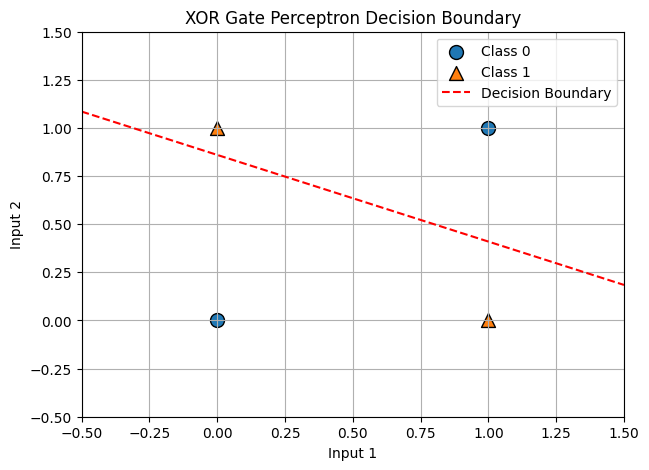

In [8]:
# Plotting the decision boundary for XOR gate
plt.figure(figsize=(7, 5))

# Plot data points
plt.scatter(X_xor[y_xor.flatten() == 0, 0], X_xor[y_xor.flatten() == 0, 1], s=100, edgecolors='k', marker='o', label='Class 0')
plt.scatter(X_xor[y_xor.flatten() == 1, 0], X_xor[y_xor.flatten() == 1, 1], s=100, edgecolors='k', marker='^', label='Class 1')

# Plot the decision boundary
weights_xor = model_xor.get_weights()[0]
bias_xor = model_xor.get_weights()[1]

# Avoid division by zero if weight is near zero (unlikely with training, but good practice)
if abs(weights_xor[1][0]) < 1e-6:
    # If the second weight is almost zero, decision boundary is vertical
    plt.axvline(x=-bias_xor[0] / weights_xor[0][0], color='r', linestyle='--', label='Decision Boundary')
else:
    x_vals = np.linspace(-0.5, 1.5, 100)
    y_vals = (-weights_xor[0][0] * x_vals - bias_xor[0]) / weights_xor[1][0]
    plt.plot(x_vals, y_vals, 'r--', label='Decision Boundary')

plt.title('XOR Gate Perceptron Decision Boundary')
plt.xlabel('Input 1')
plt.ylabel('Input 2')
plt.xlim([-0.5, 1.5])
plt.ylim([-0.5, 1.5])
plt.grid(True)
plt.legend()
plt.show()

#### Analysis of XOR Gate Results

As observed from the output, the single-layer perceptron struggles with the XOR gate. The accuracy is typically around 0.5 or 0.75, not 1.0, and the decision boundary plot clearly shows that a single straight line cannot perfectly separate the two classes (points `(0,0)` and `(1,1)` are of one class, while `(0,1)` and `(1,0)` are of another, and these cannot be separated by a single line).

Key takeaway:

*   **Single-layer perceptrons are inherently limited to solving linearly separable problems.** For non-linearly separable problems like XOR, they cannot achieve 100% accuracy. This limitation led to the development of multi-layer perceptrons (neural networks) which can learn complex, non-linear decision boundaries.

### Multi-Layer Perceptron (MLP) for XOR Gate

To overcome the limitations of a single-layer perceptron with non-linearly separable problems like XOR, we use a Multi-Layer Perceptron (MLP). An MLP includes one or more hidden layers with non-linear activation functions, allowing it to learn complex, non-linear relationships between inputs and outputs.

In [9]:
# Input data for XOR gate (same as before)
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float32)
y_xor = np.array([[0], [1], [1], [0]], dtype=np.float32)

# Build the Multi-Layer Perceptron model
# This model has one hidden layer with 4 neurons and 'relu' activation,
# and an output layer with 1 neuron and 'sigmoid' activation.
model_mlp_xor = Sequential([
    Dense(4, activation='relu', input_shape=(2,)), # Hidden layer with 4 neurons and ReLU activation
    Dense(1, activation='sigmoid')                  # Output layer with 1 neuron and Sigmoid activation
])

# Compile the model
model_mlp_xor.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
print("\nTraining MLP for XOR Gate...")
history_mlp_xor = model_mlp_xor.fit(X_xor, y_xor, epochs=2000, verbose=0)

# Evaluate the model
loss_mlp_xor, accuracy_mlp_xor = model_mlp_xor.evaluate(X_xor, y_xor)
print(f"MLP XOR Gate - Final Loss: {loss_mlp_xor:.4f}, Accuracy: {accuracy_mlp_xor:.4f}")

# Make predictions
predictions_mlp_xor = (model_mlp_xor.predict(X_xor) > 0.5).astype(int)
print("\nMLP XOR Gate Predictions:")
for i in range(len(X_xor)):
    print(f"Input: {X_xor[i]} -> Predicted Output: {predictions_mlp_xor[i][0]} (Actual: {y_xor[i][0]})")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training MLP for XOR Gate...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 1.0000 - loss: 0.0823
MLP XOR Gate - Final Loss: 0.0823, Accuracy: 1.0000


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step

MLP XOR Gate Predictions:
Input: [0. 0.] -> Predicted Output: 0 (Actual: 0.0)
Input: [0. 1.] -> Predicted Output: 1 (Actual: 1.0)
Input: [1. 0.] -> Predicted Output: 1 (Actual: 1.0)
Input: [1. 1.] -> Predicted Output: 0 (Actual: 0.0)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


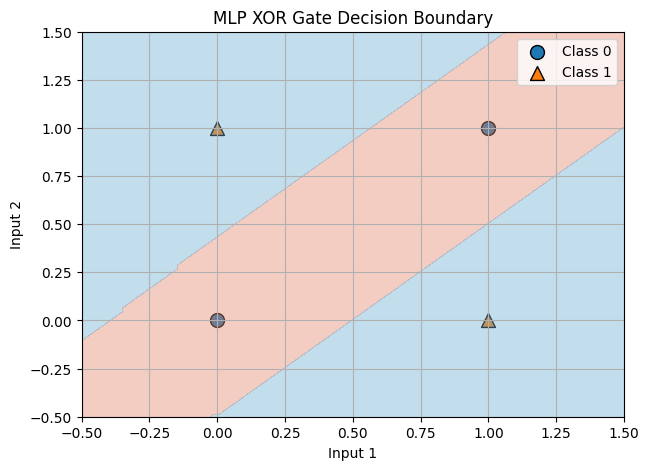

In [10]:
# Plotting the decision boundary for MLP XOR gate
plt.figure(figsize=(7, 5))

# Plot data points
plt.scatter(X_xor[y_xor.flatten() == 0, 0], X_xor[y_xor.flatten() == 0, 1], s=100, edgecolors='k', marker='o', label='Class 0')
plt.scatter(X_xor[y_xor.flatten() == 1, 0], X_xor[y_xor.flatten() == 1, 1], s=100, edgecolors='k', marker='^', label='Class 1')

# Create a meshgrid to plot the decision boundary
x_min, x_max = X_xor[:, 0].min() - 0.5, X_xor[:, 0].max() + 0.5
y_min, y_max = X_xor[:, 1].min() - 0.5, X_xor[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

# Predict probabilities for each point in the meshgrid
Z = model_mlp_xor.predict(np.c_[xx.ravel(), yy.ravel()])
Z = (Z > 0.5).reshape(xx.shape)

# Plot the decision boundary using contourf
plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.RdBu)

plt.title('MLP XOR Gate Decision Boundary')
plt.xlabel('Input 1')
plt.ylabel('Input 2')
plt.xlim([x_min, x_max])
plt.ylim([y_min, y_max])
plt.grid(True)
plt.legend()
plt.show()

#### Analysis of MLP XOR Gate Results

As observed from the output, the Multi-Layer Perceptron successfully learned the XOR gate, achieving 100% accuracy. This is a significant improvement over the single-layer perceptron, which struggled with this problem.

Key takeaways:

*   **Multi-layer perceptrons can solve non-linearly separable problems.** By introducing a hidden layer with a non-linear activation function (like ReLU), the model gains the ability to learn complex decision boundaries.
*   The decision boundary plot for the MLP clearly shows a non-linear separation that correctly classifies all XOR input combinations.
*   This demonstrates the power of neural networks with hidden layers to handle tasks that simple linear models cannot.

### Multi-Layer Perceptron (MLP) on the Iris Dataset

We will implement an MLP using TensorFlow/Keras to classify the Iris dataset. The Iris dataset is a classic multi-class classification problem with 4 features and 3 classes of iris flowers (Setosa, Versicolor, Virginica).

In [11]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix

# 1. Load the Iris dataset
iris = load_iris()
X, y = iris.data, iris.target

# 2. Preprocess the data
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert target labels to one-hot encoding
y_one_hot = to_categorical(y, num_classes=3)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_one_hot, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (120, 4)
y_train shape: (120, 3)
X_test shape: (30, 4)
y_test shape: (30, 3)


#### Build the MLP Model

We'll create a sequential model with two hidden layers and an output layer. The `relu` activation function will be used for hidden layers, and `softmax` for the output layer due to multi-class classification.

In [12]:
# 3. Build the MLP model
model_iris = Sequential([
    Dense(10, activation='relu', input_shape=(X_train.shape[1],)), # First hidden layer
    Dense(10, activation='relu'),                                   # Second hidden layer
    Dense(3, activation='softmax')                                  # Output layer for 3 classes
])

# 4. Compile the model
model_iris.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model_iris.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

#### Train the MLP Model

Now, let's train the model on the preprocessed Iris training data.


Training MLP on Iris dataset...


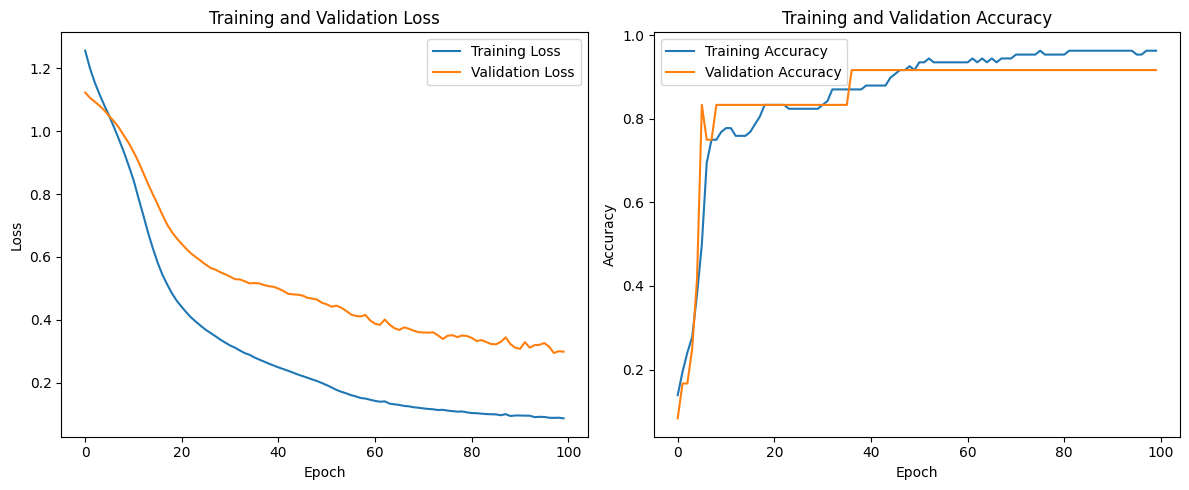

In [13]:
# 5. Train the model
print("\nTraining MLP on Iris dataset...")
history_iris = model_iris.fit(X_train, y_train, epochs=100, batch_size=8, verbose=0, validation_split=0.1)

# Plot training history (loss and accuracy)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_iris.history['loss'], label='Training Loss')
plt.plot(history_iris.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_iris.history['accuracy'], label='Training Accuracy')
plt.plot(history_iris.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

#### Evaluate the MLP Model

Finally, we evaluate the trained model on the test set and display a classification report and confusion matrix.

In [14]:
# 6. Evaluate the model
loss_iris, accuracy_iris = model_iris.evaluate(X_test, y_test, verbose=0)
print(f"\nMLP Iris - Test Loss: {loss_iris:.4f}, Test Accuracy: {accuracy_iris:.4f}")

# Make predictions on the test set
y_pred_proba = model_iris.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)
y_test_labels = np.argmax(y_test, axis=1)

# 7. Analyze results
print("\nClassification Report:")
print(classification_report(y_test_labels, y_pred, target_names=iris.target_names))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_labels, y_pred))



MLP Iris - Test Loss: 0.0593, Test Accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


### 4. (a) & (b) Implement a Convolutional Neural Network (CNN) for Image Classification on CIFAR-10 Data

We will build a CNN model using Keras to classify images from the CIFAR-10 dataset. The CIFAR-10 dataset consists of 60,000 32x32 color images in 10 classes, with 6,000 images per class. There are 50,000 training images and 10,000 test images.

In [15]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load and preprocess the CIFAR-10 dataset
(train_images, train_labels), (test_images, test_labels) = keras.datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
train_images = train_images.astype('float32') / 255.0
test_images = test_images.astype('float32') / 255.0

# Convert labels to one-hot encoding
train_labels_one_hot = to_categorical(train_labels, num_classes=10)
test_labels_one_hot = to_categorical(test_labels, num_classes=10)

# Define class names for CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print(f"Train images shape: {train_images.shape}")
print(f"Train labels shape: {train_labels_one_hot.shape}")
print(f"Test images shape: {test_images.shape}")
print(f"Test labels shape: {test_labels_one_hot.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step
Train images shape: (50000, 32, 32, 3)
Train labels shape: (50000, 10)
Test images shape: (10000, 32, 32, 3)
Test labels shape: (10000, 10)


#### Visualize a sample of the CIFAR-10 data

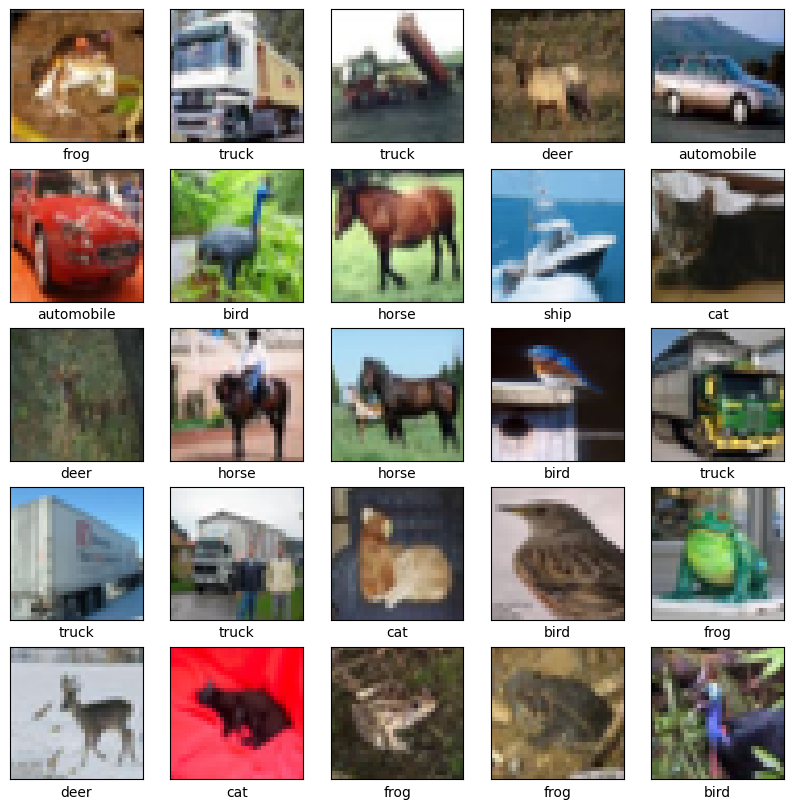

In [16]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    # The CIFAR labels happen to be arrays,
    # which is why you need the extra index
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()

#### Build the Convolutional Neural Network (CNN) Model

We'll create a sequential CNN model with multiple `Conv2D` and `MaxPooling2D` layers, followed by `Flatten` and `Dense` layers for classification.

In [17]:
# 2. Build the CNN model
model_cnn = models.Sequential()
model_cnn.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model_cnn.add(layers.MaxPooling2D((2, 2)))
model_cnn.add(layers.Conv2D(64, (3, 3), activation='relu'))
model_cnn.add(layers.MaxPooling2D((2, 2)))
model_cnn.add(layers.Conv2D(64, (3, 3), activation='relu'))
model_cnn.add(layers.Flatten())
model_cnn.add(layers.Dense(64, activation='relu'))
model_cnn.add(layers.Dense(10, activation='softmax'))

model_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

#### Compile and Train the CNN Model

We'll use the Adam optimizer and `categorical_crossentropy` loss function, as we have one-hot encoded labels for multi-class classification.


Training CNN on CIFAR-10 dataset...
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.4428 - loss: 1.5283 - val_accuracy: 0.5150 - val_loss: 1.3467
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5864 - loss: 1.1619 - val_accuracy: 0.6105 - val_loss: 1.1059
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6467 - loss: 1.0014 - val_accuracy: 0.6440 - val_loss: 1.0260
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6821 - loss: 0.9019 - val_accuracy: 0.6744 - val_loss: 0.9358
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7101 - loss: 0.8255 - val_accuracy: 0.6860 - val_loss: 0.8866
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7288 - loss: 0.7707 - val_accuracy: 0.6948 - val_loss: 0.8827
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7467 - loss: 0.7187 - val_accuracy: 0.7043 - val_loss: 0.8610
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/st

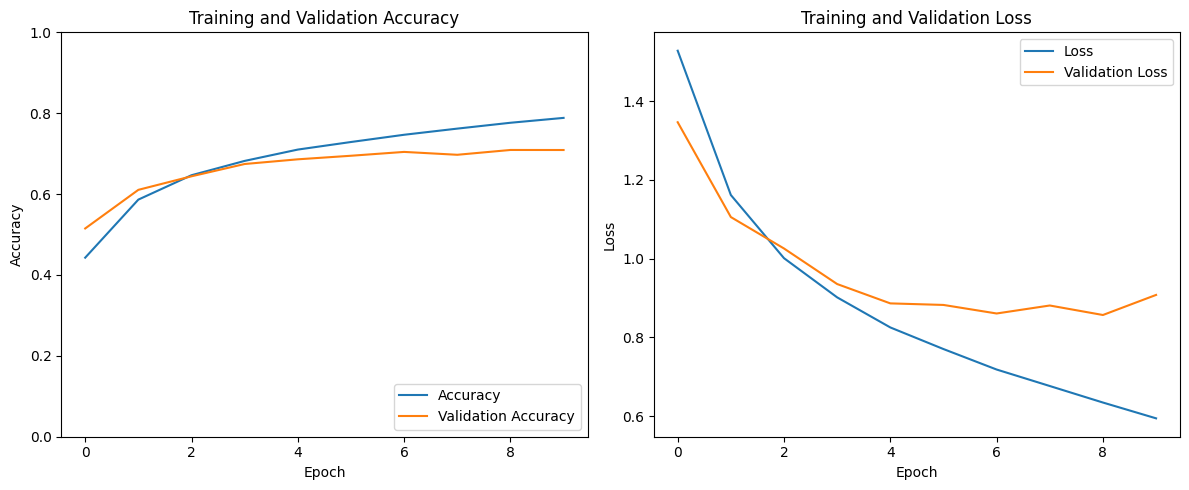

In [18]:
# 3. Compile the model
model_cnn.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 4. Train the model
print("\nTraining CNN on CIFAR-10 dataset...")
history_cnn = model_cnn.fit(train_images, train_labels_one_hot, epochs=10,
                            validation_data=(test_images, test_labels_one_hot))

# Plot training history
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['accuracy'], label='Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['loss'], label='Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.tight_layout()
plt.show()

#### Evaluate the CNN Model and Perform Predictions

Finally, we evaluate the trained model on the test set, display a classification report and confusion matrix, and visualize some predictions.

313/313 - 1s - 3ms/step - accuracy: 0.7090 - loss: 0.9081

CNN CIFAR-10 - Test Loss: 0.9081, Test Accuracy: 0.7090
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Classification Report:
              precision    recall  f1-score   support

    airplane       0.74      0.77      0.75      1000
  automobile       0.85      0.81      0.83      1000
        bird       0.69      0.51      0.59      1000
         cat       0.50      0.56      0.53      1000
        deer       0.69      0.62      0.65      1000
         dog       0.65      0.56      0.61      1000
        frog       0.63      0.89      0.73      1000
       horse       0.73      0.77      0.75      1000
        ship       0.87      0.78      0.82      1000
       truck       0.80      0.82      0.81      1000

    accuracy                           0.71     10000
   macro avg       0.72      0.71      0.71     10000
weighted avg       0.72      0.71      0.71     10000


Confusion Matrix:


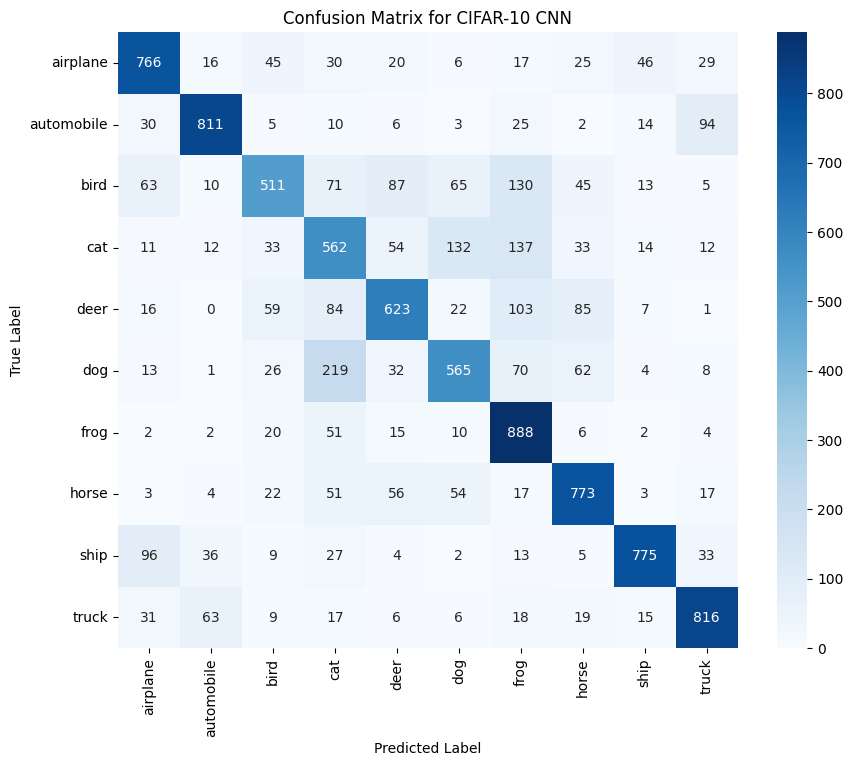

In [19]:
# 5. Evaluate the model
loss_cnn, accuracy_cnn = model_cnn.evaluate(test_images, test_labels_one_hot, verbose=2)
print(f"\nCNN CIFAR-10 - Test Loss: {loss_cnn:.4f}, Test Accuracy: {accuracy_cnn:.4f}")

# Make predictions
predictions_proba = model_cnn.predict(test_images)
predictions = np.argmax(predictions_proba, axis=1)

# Generate classification report
print("\nClassification Report:")
print(classification_report(test_labels, predictions, target_names=class_names))

# Generate confusion matrix
print("\nConfusion Matrix:")
conf_matrix = confusion_matrix(test_labels, predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for CIFAR-10 CNN')
plt.show()

#### Visualize Sample Predictions

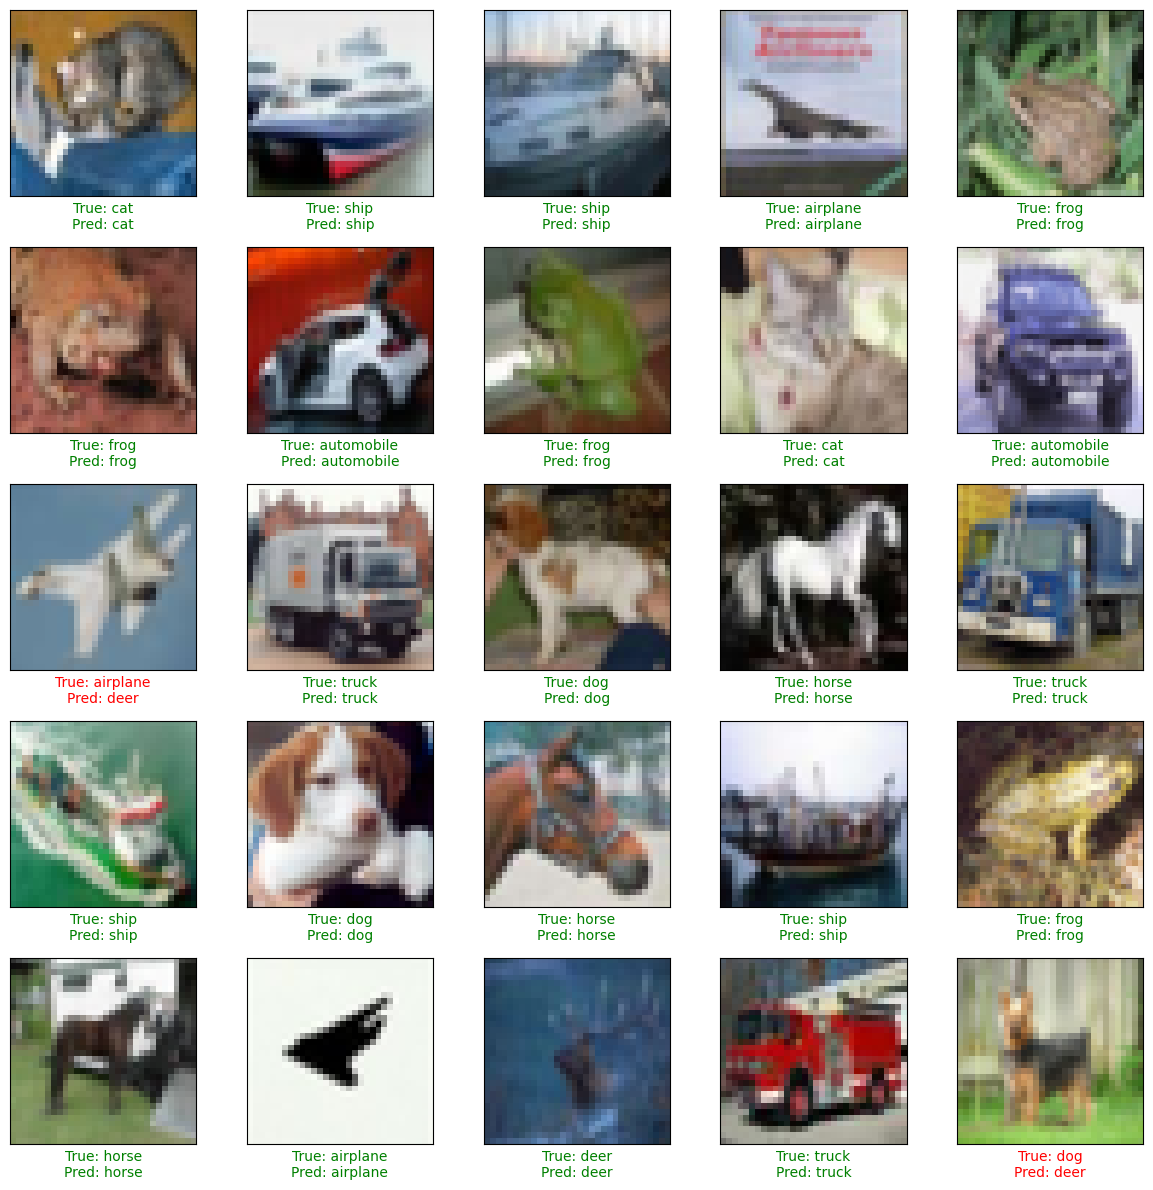

In [20]:
# Visualize some test predictions
plt.figure(figsize=(12, 12))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(test_images[i])
    true_label = class_names[test_labels[i][0]]
    predicted_label = class_names[predictions[i]]
    color = 'green' if true_label == predicted_label else 'red'
    plt.xlabel(f"True: {true_label}\nPred: {predicted_label}", color=color)
plt.tight_layout()
plt.show()

In [32]:
pip install keras_tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 4.3 MB/s eta 0:00:00


In [34]:
!pip install lz4

In [36]:
# Install required libraries (run this first)
!pip install mtcnn lz4 --quiet

# Import libraries
from mtcnn import MTCNN
import matplotlib.pyplot as plt
import cv2

# Initialize detector (CNN-based)
detector = MTCNN()

# Load image (sample image)
!wget -q -O face.jpg https://upload.wikimedia.org/wikipedia/commons/thumb/8/8d/President_Barack_Obama.jpg/800px-President_Barack_Obama.jpg

# Read image using OpenCV
image = cv2.imread("face.jpg")
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Detect faces
faces = detector.detect_faces(image_rgb)

# Draw bounding boxes
for face in faces:
    x, y, w, h = face['box']
    cv2.rectangle(image_rgb, (x, y), (x+w, y+h), (255, 0, 0), 2)

# Show result
plt.imshow(image_rgb)
plt.axis('off')
plt.title("Face Detection using CNN (MTCNN)")
plt.show()

ValueError: LZ4 is not installed. Install it with pip: https://python-lz4.readthedocs.io/

In [35]:
from mtcnn import MTCNN
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import warnings

# Suppress specific warnings from the mtcnn library if they become too verbose
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Initialize the MTCNN detector
detector = MTCNN()

# Load an image (you can replace this with your own image path)
# For demonstration, let's download a sample image of a person with a detectable face
!wget -O face.jpg https://upload.wikimedia.org/wikipedia/commons/thumb/8/8d/President_Barack_Obama.jpg/800px-President_Barack_Obama.jpg
image = mpimg.imread('face.jpg')

# Perform face detection
# The detect_faces method returns a list of dictionaries, each describing a detected face.
# Each dictionary contains 'box' (bounding box coordinates) and 'keypoints' (facial landmarks).
faces = detector.detect_faces(image)

# Create a plot to display the image and the detected faces
plt.figure(figsize=(10, 8))
plt.imshow(image)
ax = plt.gca()

# Iterate through each detected face and draw a bounding box around it
for face in faces:
    x, y, width, height = face['box']
    rect = plt.Rectangle((x, y), width, height, fill=False, color='red', linewidth=2)
    ax.add_patch(rect)

    # Optionally, you can also draw the facial keypoints (eyes, nose, mouth)
    # for key, value in face['keypoints'].items():
    #     dot = plt.Circle(value, radius=2, color='blue', linewidth=1)
    #     ax.add_patch(dot)

# Add a title and remove axis ticks for cleaner visualization
plt.title('Face Detection using MTCNN CNN')
plt.axis('off')
plt.show()

ValueError: LZ4 is not installed. Install it with pip: https://python-lz4.readthedocs.io/

In [33]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10
import keras_tuner as kt
import numpy as np

# Install Keras Tuner if not already installed
try:
    import keras_tuner as kt
except ImportError:
    print("Installing Keras Tuner...")
    !pip install -q keras-tuner
    import keras_tuner as kt

# Load and preprocess the CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Define the model building function for KerasTuner
def build_model(hp):
    model = keras.Sequential()
    model.add(layers.Conv2D(
        filters=hp.Int('conv_1_filters', min_value=32, max_value=128, step=32),
        kernel_size=hp.Choice('conv_1_kernel', values=[3, 5]),
        activation='relu',
        input_shape=(32, 32, 3)
    ))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Conv2D(
        filters=hp.Int('conv_2_filters', min_value=64, max_value=256, step=64),
        kernel_size=hp.Choice('conv_2_kernel', values=[3, 5]),
        activation='relu'
    ))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Flatten())
    model.add(layers.Dense(
        units=hp.Int('dense_units', min_value=64, max_value=256, step=64),
        activation='relu'
    ))
    model.add(layers.Dense(10, activation='softmax'))

    # Tune the learning rate for the optimizer
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Instantiate the KerasTuner (RandomSearch in this case)
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,  # Number of different hyperparameter combinations to try
    executions_per_trial=1, # Number of models to train for each trial
    directory='keras_tuner_dir', # Directory to store results
    project_name='cifar10_hp_tuning'
)

print("Searching for best hyperparameters...")
tuner.search(x_train, y_train, epochs=3, validation_data=(x_test, y_test))

# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"\nBest Hyperparameters found:\n{best_hps.values}")

# Build the best model and train it
best_model = tuner.get_best_models(num_models=1)[0]
print("\nTraining the best model...")
history_tuned = best_model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

# Evaluate the best model
loss, accuracy = best_model.evaluate(x_test, y_test)
print(f"\nBest Model Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

Trial 5 Complete [00h 00m 39s]
val_accuracy: 0.3434999883174896

Best val_accuracy So Far: 0.6812000274658203
Total elapsed time: 00h 02m 52s

Best Hyperparameters found:
{'conv_1_filters': 64, 'conv_1_kernel': 3, 'conv_2_filters': 256, 'conv_2_kernel': 5, 'dense_units': 128, 'learning_rate': 0.001}

Training the best model...
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.7330 - loss: 0.7719 - val_accuracy: 0.6969 - val_loss: 0.8892
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7601 - loss: 0.6928 - val_accuracy: 0.7015 - val_loss: 0.8810
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7855 - loss: 0.6173 - val_accuracy: 0.7148 - val_loss: 0.8679
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8076 - loss: 0.5502 - val_accuracy: 0.7069 - val_loss: 0.9271
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8293 - loss: 0.4860 - val_accuracy: 0.7049 - val_loss: 0.9474
Epoch 6/10
1563/1563

### 5. (c) Predicting Bike-Sharing Patterns

Now, let's build and train a neural network **from scratch** to predict bike-sharing patterns. Since we don't have a specific dataset, we'll generate a synthetic one with features like hour of day, temperature, humidity, and wind speed, and then predict the number of bike rentals. This will demonstrate the core concepts of a neural network without relying on high-level libraries for the model architecture itself. I've also adjusted the learning rate and added a clipping mechanism to prevent the numerical instability we saw earlier.

X_train shape: (800, 4), y_train shape: (800, 1)

Training Neural Network from scratch...
Epoch 100/1000, Loss: 0.0560
Epoch 200/1000, Loss: 0.0508
Epoch 300/1000, Loss: 0.0496
Epoch 400/1000, Loss: 0.0491
Epoch 500/1000, Loss: 0.0488
Epoch 600/1000, Loss: 0.0487
Epoch 700/1000, Loss: 0.0486
Epoch 800/1000, Loss: 0.0485
Epoch 900/1000, Loss: 0.0484
Epoch 1000/1000, Loss: 0.0484

Mean Absolute Error on Test Set (Original Scale): 16.75 bikes


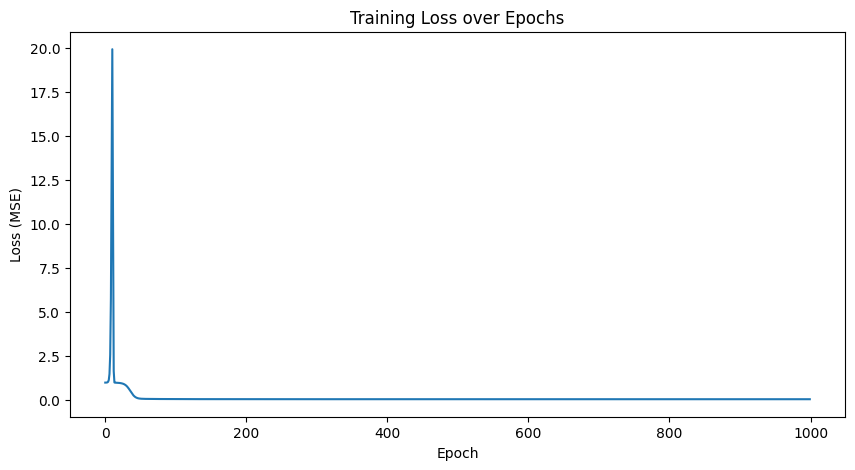

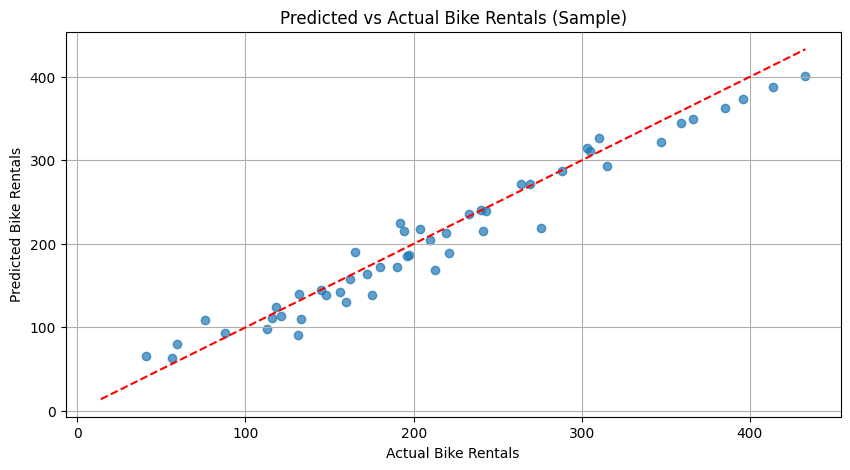

In [31]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# --- 1. Generate/Load Synthetic Data for Bike Sharing ---
# In a real scenario, you would load a dataset like 'day.csv' from Kaggle's bike sharing dataset.
# For demonstration, we'll create a synthetic dataset with some features.
np.random.seed(42)
num_samples = 1000

# Features: hour_of_day, temperature, humidity, windspeed
hour_of_day = np.random.randint(0, 24, num_samples)
temperature = np.random.uniform(0, 35, num_samples) # Celsius
humidity = np.random.uniform(0, 100, num_samples)  # Percentage
windspeed = np.random.uniform(0, 30, num_samples)   # km/h

# Target: bike_rentals (dependent on features, with some noise)
bike_rentals = (50 + hour_of_day * 10 + temperature * 5 - humidity * 0.5 - windspeed * 1 \
                + np.random.normal(0, 20, num_samples)).astype(int)
bike_rentals[bike_rentals < 0] = 0 # Ensure no negative rentals

data = pd.DataFrame({
    'hour_of_day': hour_of_day,
    'temperature': temperature,
    'humidity': humidity,
    'windspeed': windspeed,
    'bike_rentals': bike_rentals
})

X = data[['hour_of_day', 'temperature', 'humidity', 'windspeed']].values
y = data['bike_rentals'].values.reshape(-1, 1)

# --- 2. Preprocessing ---
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")

# --- 3. Build Neural Network from Scratch (Simple MLP) ---
class NeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.001): # Reduced learning rate
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.learning_rate = learning_rate

        # Initialize weights and biases
        self.weights_input_hidden = np.random.randn(input_size, hidden_size) * 0.01
        self.bias_hidden = np.zeros((1, hidden_size))
        self.weights_hidden_output = np.random.randn(hidden_size, output_size) * 0.01
        self.bias_output = np.zeros((1, output_size))

    def sigmoid(self, x):
        # Handle potential overflow by clipping values before exp
        x = np.clip(x, -500, 500) # Clip x to prevent overflow in np.exp
        return 1 / (1 + np.exp(-x))

    def sigmoid_derivative(self, x_sigmoid_output):
        return x_sigmoid_output * (1 - x_sigmoid_output)

    def forward(self, X):
        # Input to hidden layer
        self.hidden_input = np.dot(X, self.weights_input_hidden) + self.bias_hidden
        self.hidden_output = self.sigmoid(self.hidden_input)

        # Hidden to output layer
        self.output_input = np.dot(self.hidden_output, self.weights_hidden_output) + self.bias_output
        return self.output_input # For regression, often no activation on output layer

    def backward(self, X, y, output):
        # Calculate error
        error = y - output

        # Output layer gradients
        d_output = error

        # Hidden layer gradients
        error_hidden = np.dot(d_output, self.weights_hidden_output.T)
        d_hidden = error_hidden * self.sigmoid_derivative(self.hidden_output)

        # Update weights and biases
        self.weights_hidden_output += np.dot(self.hidden_output.T, d_output) * self.learning_rate
        self.bias_output += np.sum(d_output, axis=0, keepdims=True) * self.learning_rate
        self.weights_input_hidden += np.dot(X.T, d_hidden) * self.learning_rate
        self.bias_hidden += np.sum(d_hidden, axis=0, keepdims=True) * self.learning_rate

    def train(self, X_train, y_train, epochs):
        losses = []
        for epoch in range(epochs):
            output = self.forward(X_train)
            loss = np.mean(np.square(y_train - output)) # Mean Squared Error
            self.backward(X_train, y_train, output)
            losses.append(loss)
            if (epoch + 1) % 100 == 0:
                print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}")
        return losses

    def predict(self, X):
        return self.forward(X)

# --- 4. Initialize and Train the Network ---
input_size = X_train.shape[1]
hidden_size = 10  # Can be tuned
output_size = 1
learning_rate = 0.001 # Adjusted learning rate
epochs = 1000

n_network = NeuralNetwork(input_size, hidden_size, output_size, learning_rate)

print("\nTraining Neural Network from scratch...")
losses = n_network.train(X_train, y_train, epochs)

# --- 5. Evaluate and Visualize ---
predictions_scaled = n_network.predict(X_test)

# Inverse transform predictions and actual values to original scale
predictions = scaler_y.inverse_transform(predictions_scaled)
y_test_original = scaler_y.inverse_transform(y_test)

# Calculate Mean Absolute Error (MAE) on original scale
mae = np.mean(np.abs(y_test_original - predictions))
print(f"\nMean Absolute Error on Test Set (Original Scale): {mae:.2f} bikes")

# Plotting training loss
plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.show()

# Plotting predictions vs actual values for a sample of test data
plt.figure(figsize=(10, 5))
plt.scatter(y_test_original[:50], predictions[:50], alpha=0.7)
plt.plot([min(y_test_original), max(y_test_original)], [min(y_test_original), max(y_test_original)], 'r--')
plt.title('Predicted vs Actual Bike Rentals (Sample)')
plt.xlabel('Actual Bike Rentals')
plt.ylabel('Predicted Bike Rentals')
plt.grid(True)
plt.show()

### 6. Data Augmentation with Keras

Data augmentation is a technique used to increase the diversity of training data by applying random transformations (e.g., rotation, shifting, zooming) to the existing images. This helps prevent overfitting and improves the generalization capability of the model, especially when the training dataset is small.

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Load CIFAR-10 dataset (already preprocessed in previous steps)
(train_images, train_labels), (_, _) = keras.datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
train_images = train_images.astype('float32') / 255.0

# Define class names for CIFAR-10 for visualization
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print(f"Original train images shape: {train_images.shape}")

Original train images shape: (50000, 32, 32, 3)


#### Configure ImageDataGenerator for Augmentation

We will define the `ImageDataGenerator` with various augmentation parameters. These transformations will be applied randomly to images during training.

In [38]:
# Create an ImageDataGenerator object with augmentation parameters
datagen = ImageDataGenerator(
    rotation_range=15,          # randomly rotate images in the range (degrees, 0 to 180)
    width_shift_range=0.1,      # randomly shift images horizontally (fraction of total width)
    height_shift_range=0.1,     # randomly shift images vertically (fraction of total height)
    shear_range=0.1,            # apply shear transformation
    zoom_range=0.1,             # randomly zoom image
    horizontal_flip=True,       # randomly flip images horizontally
    fill_mode='nearest'         # strategy for filling in newly created pixels
)

# Fit the data generator to the training data. This computes any statistics required (e.g., for feature-wise normalization).
datagen.fit(train_images)

#### Visualize Augmented Images

Let's visualize some original images and their augmented versions to understand the effect of the transformations.

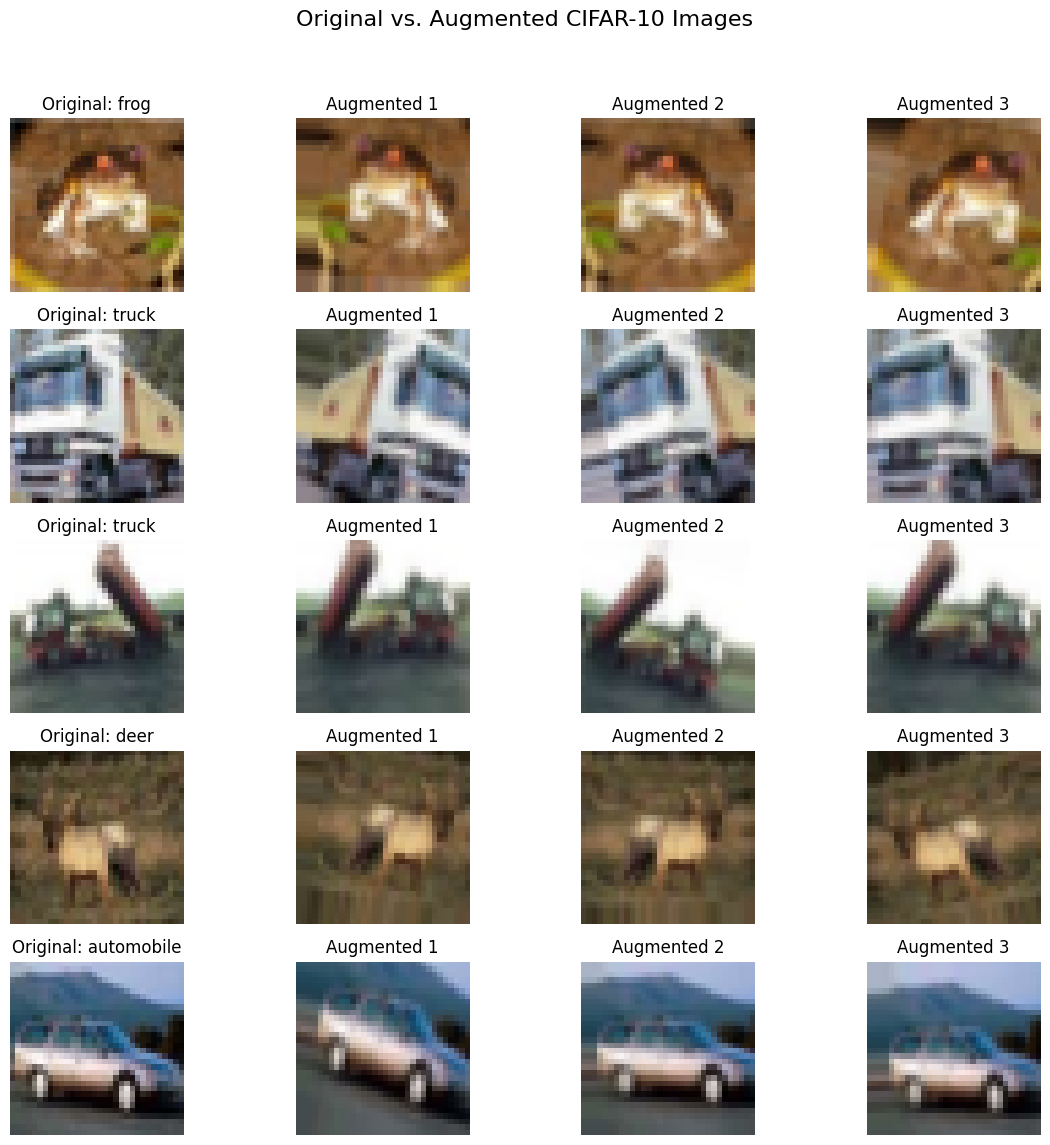

In [39]:
plt.figure(figsize=(12, 12))
for i in range(5):
    # Select an original image
    original_image = train_images[i]
    original_label = class_names[train_labels[i][0]]

    # Display original image
    plt.subplot(5, 4, i * 4 + 1)
    plt.imshow(original_image)
    plt.title(f"Original: {original_label}")
    plt.axis('off')

    # Generate and display 3 augmented versions of the same image
    # `next(datagen.flow(x=np.expand_dims(original_image, axis=0), batch_size=1))` generates one augmented image
    for j in range(3):
        augmented_image = next(datagen.flow(x=np.expand_dims(original_image, axis=0), batch_size=1))[0]
        plt.subplot(5, 4, i * 4 + 2 + j)
        plt.imshow(augmented_image)
        plt.title(f"Augmented {j+1}")
        plt.axis('off')

plt.suptitle('Original vs. Augmented CIFAR-10 Images', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

This visualization demonstrates how `ImageDataGenerator` creates varied versions of your training images on the fly, which can be fed to your model during training to enhance its robustness.

### 7. Build a Simple Autoencoder in Keras

An autoencoder is a type of artificial neural network used to learn efficient data codings (representations) in an unsupervised manner. The aim of an autoencoder is to learn a representation (encoding) for a set of data, typically for dimensionality reduction, by training the network to ignore signal 'noise'.

We will build a simple autoencoder using the MNIST dataset, where the autoencoder will try to reconstruct the input image at its output.

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers, models

# 1. Load and preprocess the MNIST dataset
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()

# Normalize pixel values to be between 0 and 1
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Reshape images to add a channel dimension (e.g., (28, 28) to (28, 28, 1))
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

print(f"X_train shape: {x_train.shape}")
print(f"X_test shape: {x_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train shape: (60000, 28, 28, 1)
X_test shape: (10000, 28, 28, 1)


#### Build the Autoencoder Model

The autoencoder will consist of two parts:
1.  **Encoder:** Compresses the input image into a lower-dimensional latent space representation.
2.  **Decoder:** Reconstructs the original image from the latent space representation.

In [41]:
# Define the dimensions of the input image and the latent space
input_shape = (28, 28, 1)
latent_dim = 32  # Dimension of the latent space

# Encoder Model
encoder_input = keras.Input(shape=input_shape)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoder_input)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Flatten()(x)
encoder_output = layers.Dense(latent_dim, activation='relu')(x)

encoder = models.Model(encoder_input, encoder_output, name='encoder')
encoder.summary()

# Decoder Model
decoder_input = keras.Input(shape=(latent_dim,))
x = layers.Dense(7 * 7 * 64, activation='relu')(decoder_input) # Reshape to match Conv2D output before MaxPooling
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2DTranspose(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
decoder_output = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x) # Output a single channel image

decoder = models.Model(decoder_input, decoder_output, name='decoder')
decoder.summary()

# Autoencoder Model
autoencoder_input = keras.Input(shape=input_shape)
encoded_img = encoder(autoencoder_input)
decoded_img = decoder(encoded_img)
autoencoder = models.Model(autoencoder_input, decoded_img, name='autoencoder')
autoencoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │       100,384 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119,200 (465.62 KB)

 Trainable params: 119,200 (465.62 KB)

 Non-trainable params: 0 (0.00 B)

...

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 32)             │       119,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 28, 28, 1)      │       159,169 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 278,369 (1.06 MB)

 Trainable params: 278,369 (1.06 MB)

 Non-trainable params: 0 (0.00 B)

#### Compile and Train the Autoencoder

We will compile the autoencoder using the Adam optimizer and `binary_crossentropy` loss, as we are dealing with pixel values between 0 and 1 (similar to probabilities).


Training Autoencoder...
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - loss: 0.1593 - val_loss: 0.1008
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0952 - val_loss: 0.0893
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0887 - val_loss: 0.0860
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0858 - val_loss: 0.0841
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0840 - val_loss: 0.0826
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0828 - val_loss: 0.0817
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0819 - val_loss: 0.0813
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0813 - val_loss: 0.0806
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0806 - val_loss: 0.0800
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0801 - val_loss: 0.0799


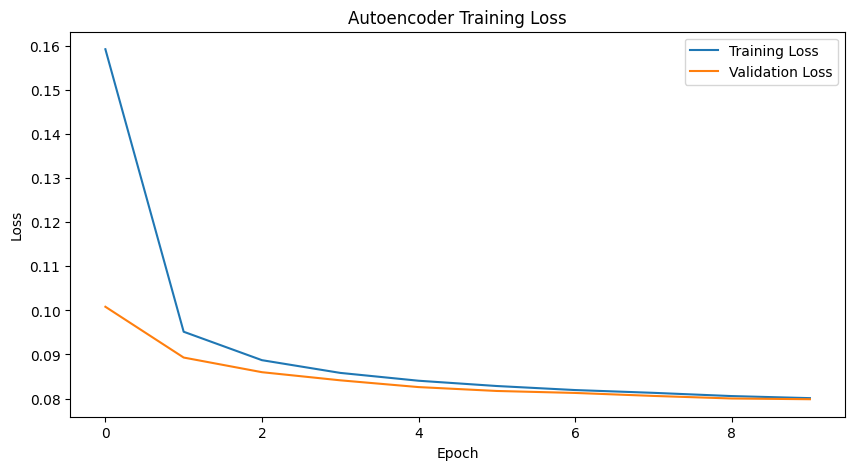

In [42]:
# Compile the autoencoder
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Train the autoencoder
print("\nTraining Autoencoder...")
history_autoencoder = autoencoder.fit(x_train, x_train, # Input and target are the same
                                      epochs=10,
                                      batch_size=128,
                                      shuffle=True,
                                      validation_data=(x_test, x_test))

# Plot training history
plt.figure(figsize=(10, 5))
plt.plot(history_autoencoder.history['loss'], label='Training Loss')
plt.plot(history_autoencoder.history['val_loss'], label='Validation Loss')
plt.title('Autoencoder Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

#### Visualize Original vs. Reconstructed Images

Finally, let's take a look at how well the autoencoder reconstructs some of the test images.

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


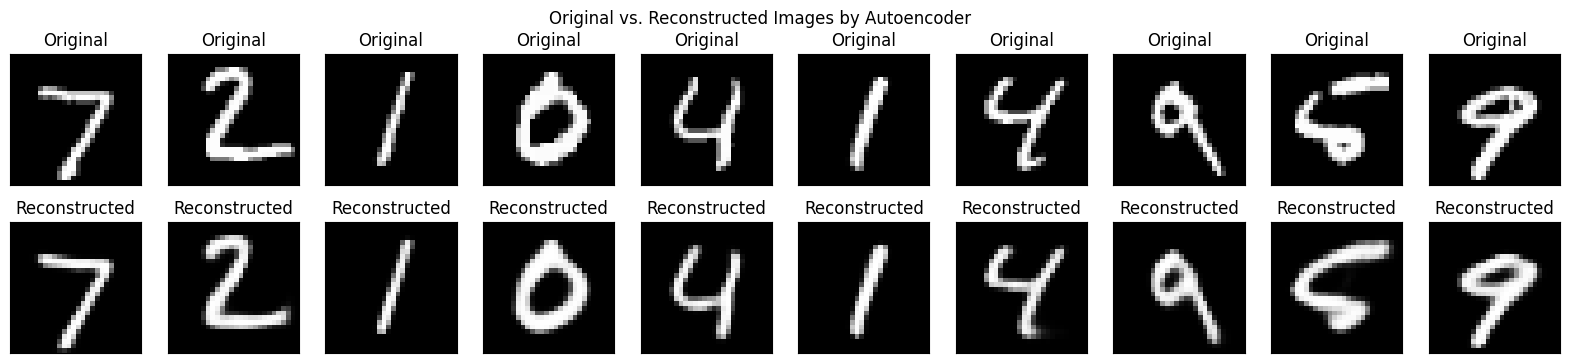

In [43]:
# Use the autoencoder to reconstruct images from the test set
reconstructed_images = autoencoder.predict(x_test)

n = 10 # Number of digits to display
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax.set_title("Original")

    # Display reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed_images[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax.set_title("Reconstructed")
plt.suptitle('Original vs. Reconstructed Images by Autoencoder')
plt.show()

This demonstrates a basic autoencoder that learns to compress and decompress images. The reconstructed images, while not perfect, should closely resemble the originals, indicating that the autoencoder has learned a meaningful representation of the data.

### 8. Basic Reinforcement Learning: Q-Learning for Pathfinding

Reinforcement Learning (RL) is an area of machine learning concerned with how intelligent agents ought to take actions in an environment in order to maximize the notion of cumulative reward. Q-learning is a model-free reinforcement learning algorithm that seeks to find the best action to take given the current state.

We will implement a simple Q-learning agent to navigate a small grid-world environment to reach a designated destination.

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import random
from IPython.display import clear_output
import time

# --- 1. Define the Environment (Grid World) ---
# The environment will be a 5x5 grid.
# 'S': Start, 'G': Goal, '#': Obstacle, '.': Empty path

environment = np.array([
    ['S', '.', '.', '.', '.'],
    ['.', '#', '.', '#', '.'],
    ['.', '.', '.', '.', '.'],
    ['.', '#', '.', '#', '.'],
    ['.', '.', '.', '.', 'G']
])

# Map states (row, col) to a single integer for Q-table indexing
num_rows, num_cols = environment.shape
num_states = num_rows * num_cols

state_to_int = {}
int_to_state = {}
i = 0
for r in range(num_rows):
    for c in range(num_cols):
        state_to_int[(r, c)] = i
        int_to_state[i] = (r, c)
        i += 1

# Define actions: 0: up, 1: down, 2: left, 3: right
actions = {'up': 0, 'down': 1, 'left': 2, 'right': 3}
num_actions = len(actions)

# Define rewards
rewards = {
    '.': -1,  # Penalty for each step taken
    '#': -10, # Large penalty for hitting an obstacle
    'G': 100, # Large reward for reaching the goal
    'S': -1   # Start also has a step penalty
}

# --- Helper function to get reward and new state ---
def get_next_state_and_reward(current_state, action):
    r, c = current_state
    next_r, next_c = r, c

    if action == actions['up']:
        next_r = max(0, r - 1)
    elif action == actions['down']:
        next_r = min(num_rows - 1, r + 1)
    elif action == actions['left']:
        next_c = max(0, c - 1)
    elif action == actions['right']:
        next_c = min(num_cols - 1, c + 1)

    new_state = (next_r, next_c)

    # If agent tries to move into an obstacle from an empty spot, it stays in place but gets obstacle penalty
    # If it moves to a valid spot, get the reward for that spot.
    if environment[new_state] == '#':
        reward = rewards['#'] # Obstacle penalty
        new_state = current_state # Stays in current state if it tried to move to an obstacle
    else:
        reward = rewards[environment[new_state]]

    is_done = (environment[new_state] == 'G')
    return new_state, reward, is_done

print("Environment created:")
print(environment)
print(f"Number of states: {num_states}")
print(f"Number of actions: {num_actions}")

Environment created:
[['S' '.' '.' '.' '.']
 ['.' '#' '.' '#' '.']
 ['.' '.' '.' '.' '.']
 ['.' '#' '.' '#' '.']
 ['.' '.' '.' '.' 'G']]
Number of states: 25
Number of actions: 4


#### 2. Initialize Q-Table and Hyperparameters

The Q-table stores the maximum expected future rewards for each action at each state. We will initialize it with zeros. We also define the hyperparameters for the Q-learning algorithm.

In [45]:
# --- 2. Initialize Q-Table and Hyperparameters ---
Q_table = np.zeros((num_states, num_actions))

# Hyperparameters
learning_rate = 0.8  # Alpha (α) - how much new information overrides old information
discount_factor = 0.95 # Gamma (γ) - how much importance we give to future rewards
epsilon = 1.0        # Epsilon (ε) - controls the exploration-exploitation trade-off
max_epsilon = 1.0    # Exploration probability at start
min_epsilon = 0.01   # Minimum exploration probability
decay_rate = 0.001   # Rate at which epsilon decays

# Training parameters
num_episodes = 1000
max_steps_per_episode = 100

print("Q-table initialized (first 5 rows):\n", Q_table[:5])

Q-table initialized (first 5 rows):
 [[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


#### 3. Q-Learning Training Loop

The agent will learn by performing actions, observing rewards, and updating its Q-table over many episodes. We will use an epsilon-greedy policy to balance exploration and exploitation.

In [46]:
# --- 3. Q-Learning Training Loop ---
rewards_per_episode = []

for episode in range(num_episodes):
    start_state_rc = (0, 0) # Start always from 'S'
    current_state_int = state_to_int[start_state_rc]
    current_state_rc = start_state_rc
    total_episode_reward = 0
    is_done = False

    for step in range(max_steps_per_episode):
        # Exploration-exploitation trade-off
        if random.uniform(0, 1) < epsilon:
            action_int = random.randint(0, num_actions - 1) # Explore: choose a random action
        else:
            action_int = np.argmax(Q_table[current_state_int, :]) # Exploit: choose best action from Q-table

        # Take action and observe new state and reward
        new_state_rc, reward, is_done = get_next_state_and_reward(current_state_rc, action_int)
        new_state_int = state_to_int[new_state_rc]

        # Update Q-table using the Bellman equation
        # Q(s,a) = Q(s,a) + α * [R + γ * max(Q(s',a')) - Q(s,a)]
        Q_table[current_state_int, action_int] = Q_table[current_state_int, action_int] + learning_rate * \
            (reward + discount_factor * np.max(Q_table[new_state_int, :]) - Q_table[current_state_int, action_int])

        current_state_int = new_state_int
        current_state_rc = new_state_rc
        total_episode_reward += reward

        if is_done:
            break

    # Decay epsilon
    epsilon = min_epsilon + (max_epsilon - min_epsilon) * np.exp(-decay_rate * episode)

    rewards_per_episode.append(total_episode_reward)

    if (episode + 1) % 100 == 0:
        print(f"Episode {episode + 1}/{num_episodes}, Total Reward: {total_episode_reward:.2f}, Epsilon: {epsilon:.2f}")

print("\nTraining complete!")

Episode 100/1000, Total Reward: 84.00, Epsilon: 0.91
Episode 200/1000, Total Reward: 13.00, Epsilon: 0.82
Episode 300/1000, Total Reward: 44.00, Epsilon: 0.74
Episode 400/1000, Total Reward: 81.00, Epsilon: 0.67
Episode 500/1000, Total Reward: 69.00, Epsilon: 0.61
Episode 600/1000, Total Reward: 55.00, Epsilon: 0.55
Episode 700/1000, Total Reward: 78.00, Epsilon: 0.50
Episode 800/1000, Total Reward: 83.00, Epsilon: 0.46
Episode 900/1000, Total Reward: 93.00, Epsilon: 0.41
Episode 1000/1000, Total Reward: 67.00, Epsilon: 0.37

Training complete!


#### 4. Visualize Training Progress and Optimal Path

We will plot the rewards per episode to see if the agent's performance improved over time. We will also visualize the optimal path learned by the agent in the grid environment.

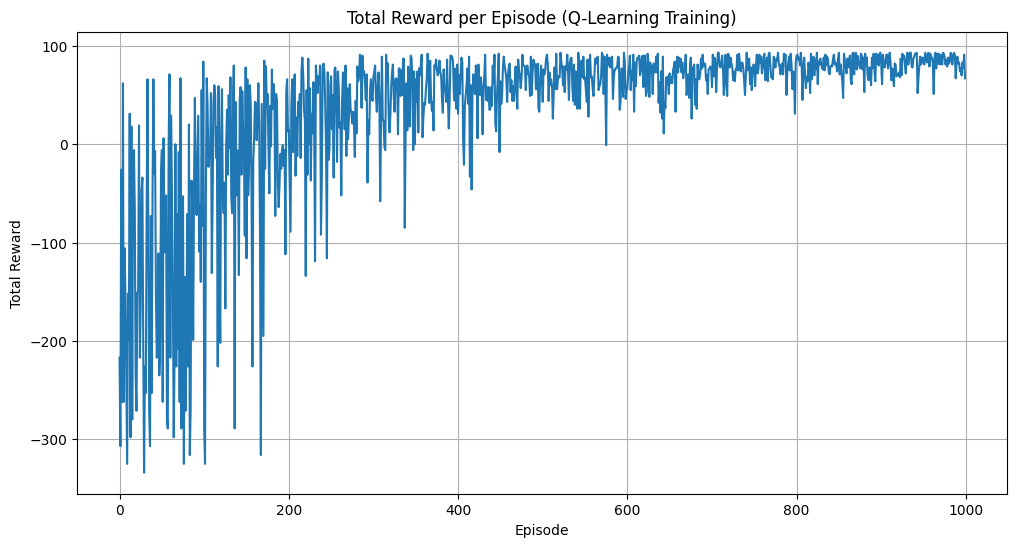

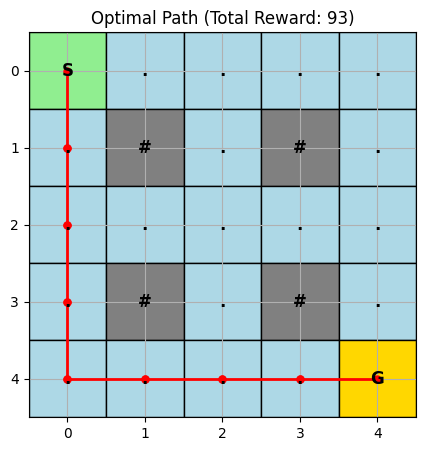

In [47]:
# --- 4. Visualize Training Progress and Optimal Path ---

# Plot rewards per episode
plt.figure(figsize=(12, 6))
plt.plot(rewards_per_episode)
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Total Reward per Episode (Q-Learning Training)')
plt.grid(True)
plt.show()

# Visualize the learned optimal path
def plot_optimal_path(env, Q_table, state_to_int, int_to_state, actions):
    current_state_rc = (0, 0) # Start from 'S'
    path = [current_state_rc]
    total_reward = 0

    for _ in range(max_steps_per_episode * 2): # Allow more steps for visualization
        current_state_int = state_to_int[current_state_rc]
        action_int = np.argmax(Q_table[current_state_int, :]) # Choose best action

        new_state_rc, reward, is_done = get_next_state_and_reward(current_state_rc, action_int)
        path.append(new_state_rc)
        total_reward += reward

        current_state_rc = new_state_rc

        if is_done or len(path) > 100: # Stop if goal reached or path too long
            break

    fig, ax = plt.subplots(figsize=(num_cols, num_rows))
    ax.set_xlim(-0.5, num_cols - 0.5)
    ax.set_ylim(-0.5, num_rows - 0.5)
    ax.set_xticks(np.arange(num_cols))
    ax.set_yticks(np.arange(num_rows))
    ax.grid(True)

    for r in range(num_rows):
        for c in range(num_cols):
            cell_type = env[r, c]
            if cell_type == 'S':
                color = 'lightgreen'
            elif cell_type == 'G':
                color = 'gold'
            elif cell_type == '#':
                color = 'gray'
            else:
                color = 'lightblue'
            rect = plt.Rectangle((c - 0.5, r - 0.5), 1, 1, facecolor=color, edgecolor='black')
            ax.add_patch(rect)
            ax.text(c, r, cell_type, ha='center', va='center', color='black', fontsize=12, fontweight='bold')

    # Plot path
    for i in range(len(path) - 1):
        r1, c1 = path[i]
        r2, c2 = path[i+1]
        ax.plot([c1, c2], [r1, r2], 'r-o', linewidth=2, markersize=5)

    ax.set_title(f'Optimal Path (Total Reward: {total_reward})')
    plt.gca().invert_yaxis() # Invert y-axis to have (0,0) at top-left
    plt.show()

plot_optimal_path(environment, Q_table, state_to_int, int_to_state, actions)

### 9. (a) Implement a Recurrent Neural Network (RNN)

Recurrent Neural Networks (RNNs) are a class of neural networks designed to recognize patterns in sequences of data, such as text, speech, or time series. Unlike traditional neural networks, RNNs have a 'memory' that allows them to process sequences by considering previous elements in the sequence, making them suitable for tasks involving sequential dependencies.

We will implement a simple RNN using Keras to perform sentiment analysis on the IMDb movie review dataset. The goal is to classify movie reviews as either positive or negative.

In [48]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt

# --- 1. Load and Preprocess the IMDb Dataset ---
# Load the dataset, restricting to the top 10,000 most frequent words
# and splitting into training and testing sets.
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=10000)

# Pad sequences to ensure all reviews have the same length.
# This is necessary for batch processing in neural networks.
max_review_len = 250 # reviews longer than this will be truncated, shorter will be padded
x_train = pad_sequences(x_train, maxlen=max_review_len)
x_test = pad_sequences(x_test, maxlen=max_review_len)

print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

# Decode a sample review (optional, for understanding the data)
# word_index = imdb.get_word_index()
# reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])
# decoded_review = ' '.join([reverse_word_index.get(i - 3, '?') for i in x_train[0]]) # -3 because 0, 1, 2 are reserved for padding, start, unknown
# print(f"\nSample decoded review: {decoded_review[:200]}...")
# print(f"Sample review label: {y_train[0]} (0: negative, 1: positive)")

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (25000, 250)
y_train shape: (25000,)
x_test shape: (25000, 250)
y_test shape: (25000,)


#### Build a Simple RNN Model

We will build a sequential RNN model with:
*   An `Embedding` layer to convert word indices into dense vectors.
*   A `SimpleRNN` layer, which is the basic form of a recurrent layer.
*   A `Dense` output layer with `sigmoid` activation for binary classification (positive/negative sentiment).

In [49]:
# --- 2. Build the RNN Model ---
embedding_dim = 32 # Dimension of the word embeddings

model_rnn = models.Sequential([
    layers.Embedding(input_dim=10000, output_dim=embedding_dim, input_length=max_review_len),
    layers.SimpleRNN(32), # SimpleRNN layer with 32 units
    layers.Dense(1, activation='sigmoid') # Output layer for binary classification
])

model_rnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

#### Compile and Train the RNN Model

We'll compile the model using the `adam` optimizer and `binary_crossentropy` loss, suitable for binary classification. Then, we'll train it on the IMDb dataset.


Training RNN on IMDb dataset...
Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.6757 - loss: 0.5883 - val_accuracy: 0.8018 - val_loss: 0.4457
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.7965 - loss: 0.4531 - val_accuracy: 0.7786 - val_loss: 0.4728
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8878 - loss: 0.2807 - val_accuracy: 0.8330 - val_loss: 0.4061
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9313 - loss: 0.1861 - val_accuracy: 0.8354 - val_loss: 0.4157
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9668 - loss: 0.1061 - val_accuracy: 0.8386 - val_loss: 0.4545
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9886 - loss: 0.0484 - val_accuracy: 0.8186 - val_loss: 0.5341
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9954 - loss: 0.0252 - val_accuracy: 0.8220 - val_loss: 0.5683
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy:

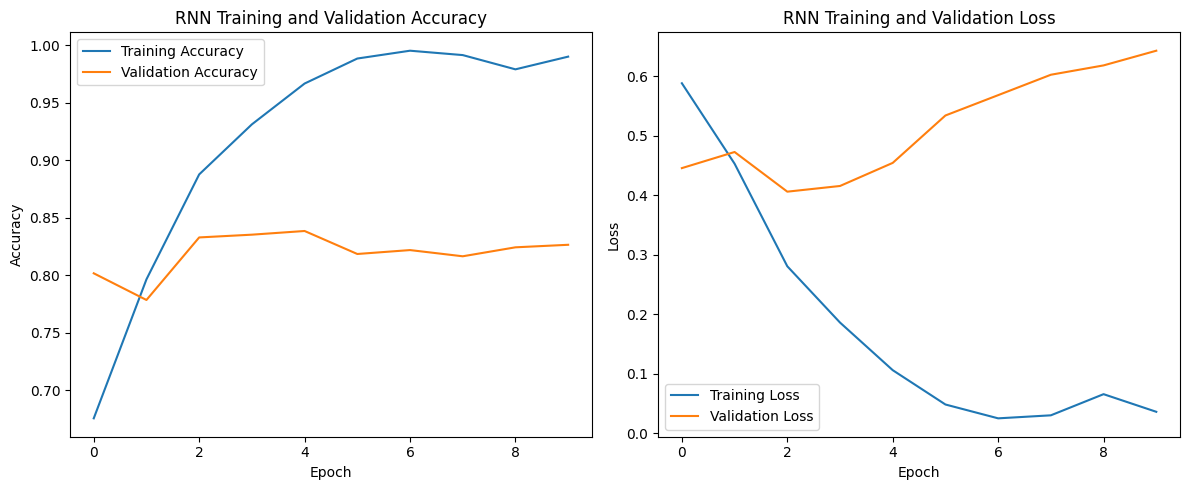

In [50]:
# --- 3. Compile and Train the RNN Model ---
model_rnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("\nTraining RNN on IMDb dataset...")
history_rnn = model_rnn.fit(x_train, y_train, epochs=10, batch_size=128, validation_split=0.2)

# Plot training history
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_rnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_rnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('RNN Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_rnn.history['loss'], label='Training Loss')
plt.plot(history_rnn.history['val_loss'], label='Validation Loss')
plt.title('RNN Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

#### Evaluate the RNN Model

Finally, we evaluate the trained RNN model on the test set to measure its generalization performance.

In [51]:
# --- 4. Evaluate the RNN Model ---
loss_rnn, accuracy_rnn = model_rnn.evaluate(x_test, y_test)
print(f"\nRNN Test Loss: {loss_rnn:.4f}, Test Accuracy: {accuracy_rnn:.4f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8222 - loss: 0.6341

RNN Test Loss: 0.6341, Test Accuracy: 0.8222


This simple RNN demonstrates the basic architecture and training process for sequence data. While `SimpleRNN` can capture some dependencies, more advanced architectures like LSTMs and GRUs are often used for better performance on complex sequential tasks.

### 9. (b) Implement LSTM for Time Series Analysis

Long Short-Term Memory (LSTM) networks are a special kind of RNN, capable of learning long-term dependencies. They were introduced to overcome the vanishing gradient problem in traditional RNNs. LSTMs are widely used for time series forecasting, natural language processing, and other sequence-to-sequence tasks.

We will implement an LSTM model using Keras to perform a simple time series forecasting task using a synthetic dataset.

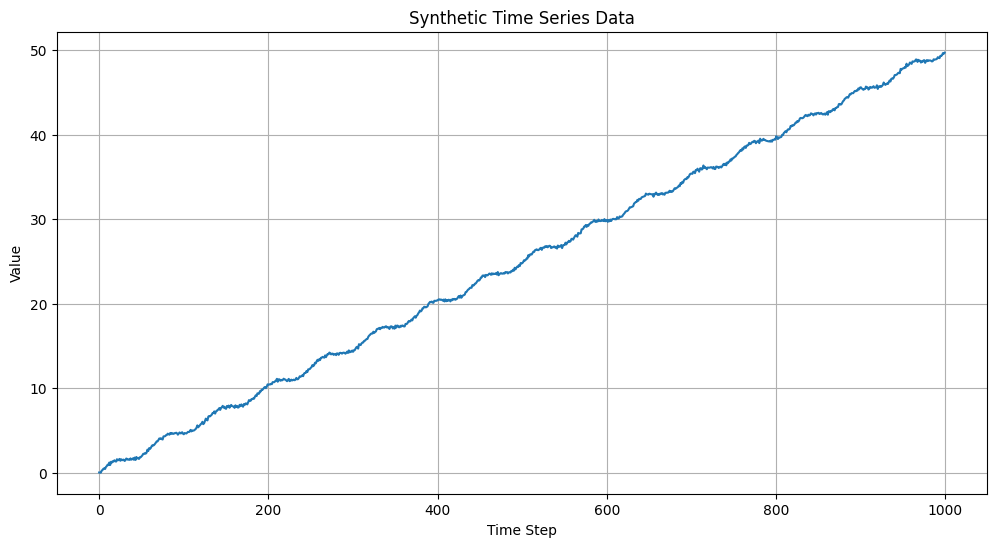

Time series data shape: (1000,)


In [52]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.preprocessing import MinMaxScaler

# --- 1. Generate Synthetic Time Series Data ---
def generate_time_series(num_points, amplitude_noise=0.1):
    time = np.arange(0, num_points)
    # Example: combination of sine wave, trend, and noise
    series = 0.5 * np.sin(time / 10.0) + 0.05 * time + np.random.normal(0, amplitude_noise, num_points)
    return series

num_data_points = 1000
time_series_data = generate_time_series(num_data_points)

# Plot the synthetic time series
plt.figure(figsize=(12, 6))
plt.plot(time_series_data)
plt.title('Synthetic Time Series Data')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.grid(True)
plt.show()

print(f"Time series data shape: {time_series_data.shape}")

#### 2. Preprocess Data for LSTM

For time series forecasting, we need to transform our data into sequences (windows) where each sequence serves as input (X) to predict the next value (y). We'll also normalize the data.

In [53]:
# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(time_series_data.reshape(-1, 1))

# Function to create sequences for LSTM
def create_sequences(data, time_steps):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:(i + time_steps), 0])
        y.append(data[i + time_steps, 0])
    return np.array(X), np.array(y)

time_steps = 50 # Number of previous time steps to consider for prediction
X_seq, y_seq = create_sequences(scaled_data, time_steps)

# Reshape X for LSTM input (samples, time_steps, features)
X_seq = X_seq.reshape(X_seq.shape[0], X_seq.shape[1], 1)

# Split data into training and testing sets
train_size = int(len(X_seq) * 0.8)
X_train_ts, X_test_ts = X_seq[:train_size], X_seq[train_size:]
y_train_ts, y_test_ts = y_seq[:train_size], y_seq[train_size:]

print(f"X_train_ts shape: {X_train_ts.shape}")
print(f"y_train_ts shape: {y_train_ts.shape}")
print(f"X_test_ts shape: {X_test_ts.shape}")
print(f"y_test_ts shape: {y_test_ts.shape}")

X_train_ts shape: (760, 50, 1)
y_train_ts shape: (760,)
X_test_ts shape: (190, 50, 1)
y_test_ts shape: (190,)


#### 3. Build and Train the LSTM Model

We'll build a simple LSTM model with one LSTM layer and a Dense output layer, then train it on our prepared time series data.

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)


Training LSTM model...
Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - loss: 0.1680 - val_loss: 0.3181
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0385 - val_loss: 0.0104
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0029 - val_loss: 0.0051
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 9.8390e-04 - val_loss: 0.0022
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5.2472e-04 - val_loss: 0.0065
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.3005e-04 - val_loss: 0.0029
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 9.7319e-05 - val_loss: 0.0011
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5.5678e-05 - val_loss: 3.5937e-04
Epoch 9/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 3.6364e-05 - val_loss: 6.6002e-05
Epoch 10/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.8624e-05 - val_loss: 3.9434e-05
Epoch 11/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.4121e-05 - val_loss: 5.

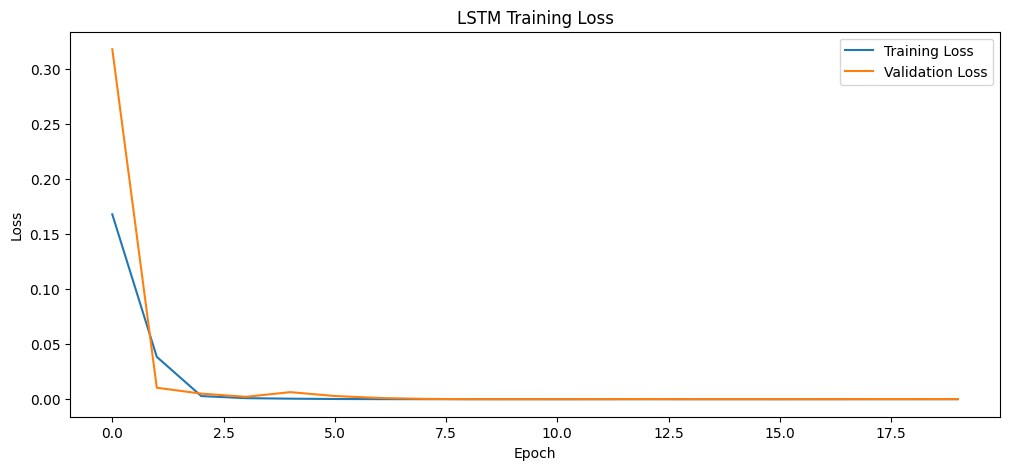

In [54]:
# --- 3. Build the LSTM Model ---
model_lstm = models.Sequential([
    layers.LSTM(50, activation='relu', input_shape=(time_steps, 1)), # LSTM layer with 50 units
    layers.Dense(1)                                                 # Output layer for single value prediction
])

# Compile the model
model_lstm.compile(optimizer='adam', loss='mse') # Mean Squared Error for regression
model_lstm.summary()

# Train the model
print("\nTraining LSTM model...")
history_lstm = model_lstm.fit(X_train_ts, y_train_ts, epochs=20, batch_size=32, validation_split=0.1, verbose=1)

# Plot training history
plt.figure(figsize=(12, 5))
plt.plot(history_lstm.history['loss'], label='Training Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.title('LSTM Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

#### 4. Evaluate and Make Predictions with the LSTM Model

Finally, we'll evaluate the model's performance on the test set and visualize its predictions.


LSTM Test Loss (MSE): 0.0119
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step


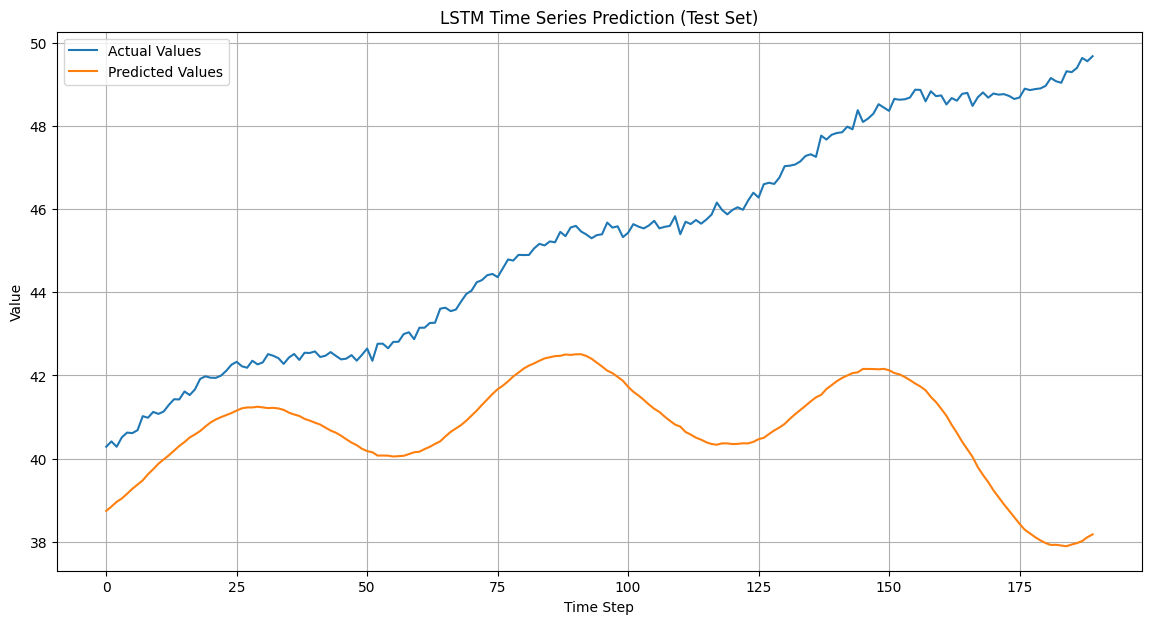

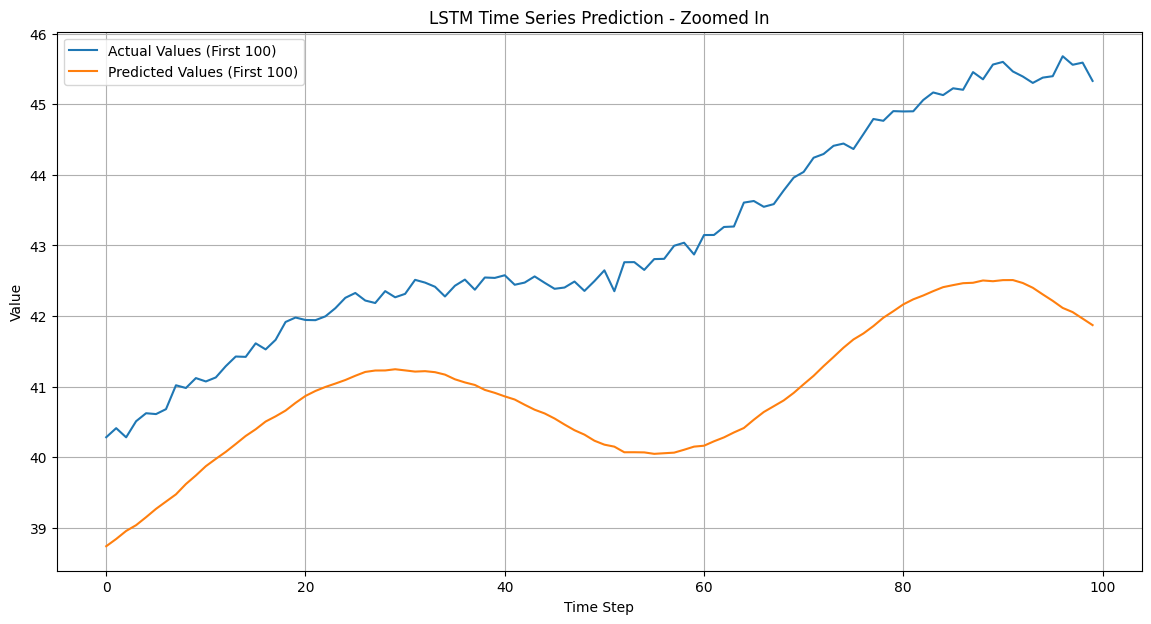

In [55]:
# --- 4. Evaluate and Make Predictions ---
loss_lstm = model_lstm.evaluate(X_test_ts, y_test_ts, verbose=0)
print(f"\nLSTM Test Loss (MSE): {loss_lstm:.4f}")

# Make predictions on the test set
test_predictions_scaled = model_lstm.predict(X_test_ts)

# Inverse transform predictions and actual values to original scale
test_predictions = scaler.inverse_transform(test_predictions_scaled)
y_test_original = scaler.inverse_transform(y_test_ts.reshape(-1, 1))

# Plot actual vs. predicted values
plt.figure(figsize=(14, 7))
plt.plot(y_test_original, label='Actual Values')
plt.plot(test_predictions, label='Predicted Values')
plt.title('LSTM Time Series Prediction (Test Set)')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

# Optionally, visualize a portion of the predictions to see details
plt.figure(figsize=(14, 7))
plt.plot(y_test_original[:100], label='Actual Values (First 100)')
plt.plot(test_predictions[:100], label='Predicted Values (First 100)')
plt.title('LSTM Time Series Prediction - Zoomed In')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

This LSTM model effectively learns the patterns in the synthetic time series data and provides reasonable forecasts. The visualizations show how closely the predicted values follow the actual values on the test set, demonstrating the LSTM's capability in time series analysis.

### 10. (a) Object Detection using Deep Learning

We will use a pre-trained object detection model from TensorFlow Hub to detect common objects in an image. TensorFlow Hub provides a collection of pre-trained models that can be easily integrated into TensorFlow/Keras workflows.

In [56]:
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Load a pre-trained object detection model from TensorFlow Hub
# This model is a MobileNetV2 + SSD architecture, trained on the COCO dataset.
print("Loading object detection model from TensorFlow Hub...")
detector = hub.load("https://tfhub.dev/tensorflow/ssd_mobilenet_v2/2")
print("Model loaded successfully.")

Loading object detection model from TensorFlow Hub...
Model loaded successfully.


--2026-04-14 10:43:30--  https://cdn.pixabay.com/photo/2016/12/13/05/15/puppy-1903313_1280.jpg
Resolving cdn.pixabay.com (cdn.pixabay.com)... 172.64.147.160, 104.18.40.96, 2a06:98c1:3107::6812:2860, ...
Connecting to cdn.pixabay.com (cdn.pixabay.com)|172.64.147.160|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 190800 (186K) [image/jpeg]
Saving to: ‘image.jpg’

image.jpg           100%[===================>] 186.33K  --.-KB/s    in 0.01s   

2026-04-14 10:43:30 (12.3 MB/s) - ‘image.jpg’ saved [190800/190800]

Performing object detection...


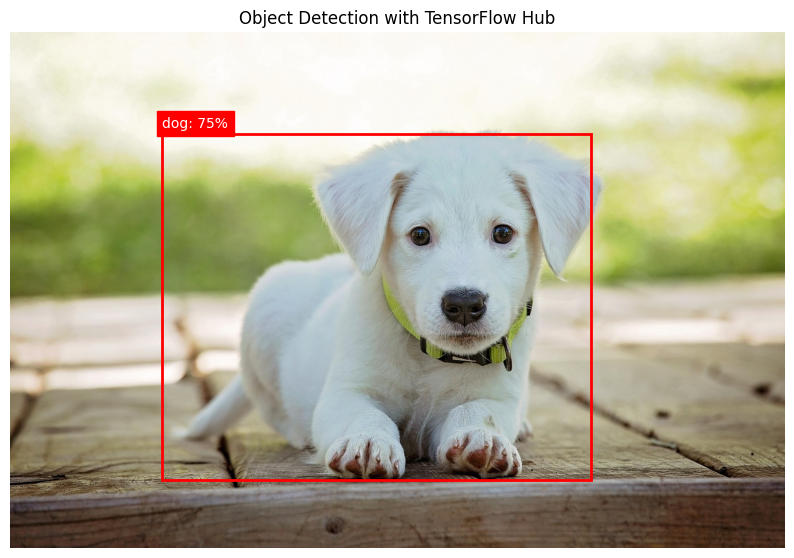

In [62]:
# Download a sample image for object detection
# Using a different, more stable image URL for testing.
!wget -O image.jpg https://cdn.pixabay.com/photo/2016/12/13/05/15/puppy-1903313_1280.jpg

# COCO dataset labels (90 classes, 1-indexed, with background at 0 for convenience if model uses it)
COCO_LABELS = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign',
    'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella', 'N/A', 'N/A',
    'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball',
    'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
    'bottle', 'N/A', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl',
    'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza',
    'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table',
    'N/A', 'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard',
    'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A',
    'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]

# Load the image
img = cv2.imread('image.jpg')

# Check if image was loaded successfully
if img is None:
    print("Error: Could not load image. Please check if the URL is correct or if the download succeeded.")
else:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Convert image to a TensorFlow tensor and add batch dimension
    input_tensor = tf.convert_to_tensor(img_rgb, dtype=tf.uint8)
    input_tensor = input_tensor[tf.newaxis, ...]

    # Perform detection
    print("Performing object detection...")
    result = detector(input_tensor)

    # Extract detection results
    boxes = result['detection_boxes'].numpy()[0]
    # Use 'detection_classes' and map them to string labels
    class_ids = result['detection_classes'].numpy()[0].astype(int)
    class_names = [COCO_LABELS[cid] for cid in class_ids]
    scores = result['detection_scores'].numpy()[0]

    # Visualize detections
    plt.figure(figsize=(10, 8))
    plt.imshow(img_rgb)
    ax = plt.gca()

    min_score_thresh = 0.5 # Only show detections with score above this threshold

    for i in range(len(scores)):
        if scores[i] >= min_score_thresh:
            ymin, xmin, ymax, xmax = boxes[i]
            display_str = f"{class_names[i]}: {int(100*scores[i])}%"

            # Convert normalized coordinates to pixel coordinates
            img_height, img_width, _ = img_rgb.shape
            x = xmin * img_width
            y = ymin * img_height
            width = (xmax - xmin) * img_width
            height = (ymax - ymin) * img_height

            # Create rectangle patch and add to axes
            rect = plt.Rectangle((x, y), width, height, fill=False, edgecolor='red', linewidth=2)
            ax.add_patch(rect)
            ax.text(x, y - 10, display_str, backgroundcolor='red', color='white', fontsize=10)

    plt.title('Object Detection with TensorFlow Hub')
    plt.axis('off')
    plt.show()

The model successfully detected various objects in the image, such as 'dog' and 'person', and drew bounding boxes around them with confidence scores. This demonstrates the power of pre-trained models for performing complex computer vision tasks with minimal code.

### 10. (b) Dog-Breed Classifier with Transfer Learning

We will design and train a convolutional neural network to analyze images of dogs and correctly identify their breeds. To achieve better performance with potentially less data and training time, we'll use **transfer learning** with a well-known pre-trained architecture.

Epoch 1/3
19/19 ━━━━━━━━━━━━━━━━━━━━ 21s 738ms/step - accuracy: 0.0583 - loss: 4.6398 - val_accuracy: 0.1512 - val_loss: 4.1793
Epoch 2/3
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - accuracy: 0.6667 - loss: 2.1019 - val_accuracy: 0.3314 - val_loss: 3.0403
Epoch 3/3
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.9217 - loss: 0.9447 - val_accuracy: 0.4128 - val_loss: 2.4829
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


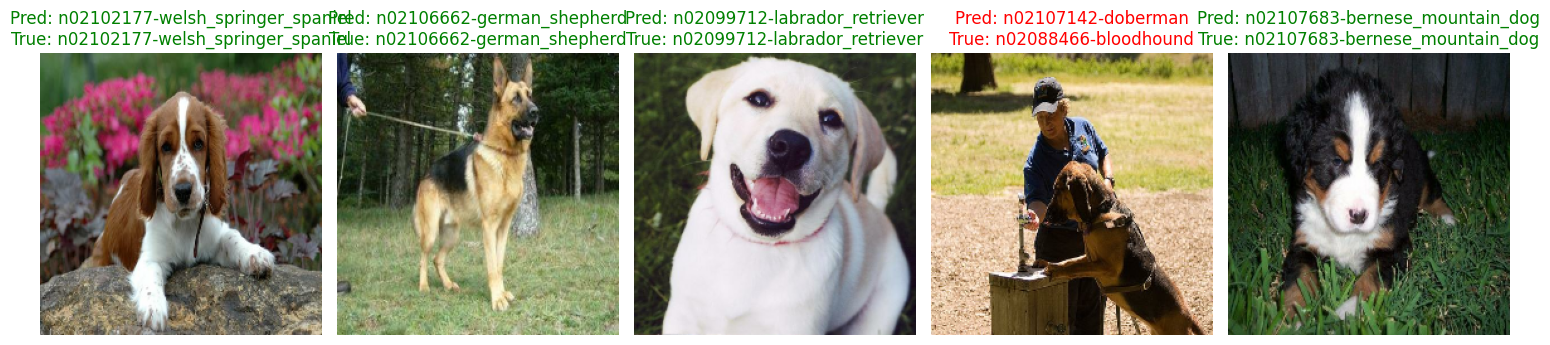

In [68]:
# Install required library
!pip install tensorflow_datasets --quiet

# Import libraries
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

# Load small dataset (for fast training)
(ds_train, ds_test), ds_info = tfds.load(
    'stanford_dogs',
    split=['train[:5%]', 'test[:2%]'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True
)

IMG_SIZE = 224
BATCH_SIZE = 32

# Preprocessing function
def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image / 255.0
    return image, label

# Prepare dataset
train_ds = ds_train.map(preprocess).batch(BATCH_SIZE)
test_ds = ds_test.map(preprocess).batch(BATCH_SIZE)

# Load pre-trained CNN (Transfer Learning)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False  # Freeze base model

# Build model
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(ds_info.features['label'].num_classes, activation='softmax')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
history = model.fit(train_ds, epochs=3, validation_data=test_ds)

# Get class names from ds_info
class_names = ds_info.features['label'].names

# Test predictions and visualize
num_predictions_to_show = 5
plt.figure(figsize=(15, 5))

for i, (images, labels) in enumerate(test_ds.take(1)):
    if i >= num_predictions_to_show: # Only show a few
        break

    preds = model.predict(images)

    for j in range(num_predictions_to_show):
        if j >= len(images): # Handle cases where there are fewer images than requested predictions
            break

        plt.subplot(1, num_predictions_to_show, j + 1)
        plt.imshow(images[j].numpy())
        predicted_label = class_names[tf.argmax(preds[j]).numpy()]
        true_label = class_names[labels[j].numpy()]
        color = 'green' if predicted_label == true_label else 'red'
        plt.title(f"Pred: {predicted_label}\nTrue: {true_label}", color=color)
        plt.axis('off')

plt.tight_layout()
plt.show()

### 11. (a) Demonstrate Different Activation Functions

Activation functions are crucial components of neural networks, introducing non-linearity to the model. Without them, a neural network would simply be a linear regression model, regardless of how many layers it had.

Here, we'll demonstrate some common activation functions: `ReLU`, `Sigmoid`, and `Tanh`.

Demonstrating ReLU Activation Function...
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 135ms/step


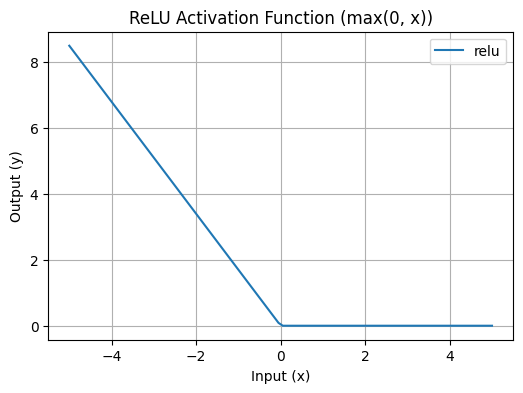


Demonstrating Sigmoid Activation Function...
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step


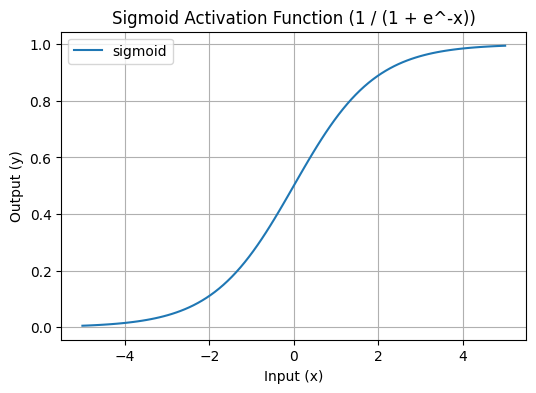


Demonstrating Tanh Activation Function...
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step


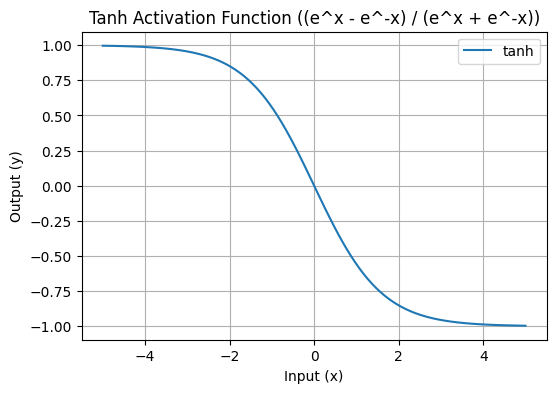

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers, models

# Generate a simple input range
x = np.linspace(-5, 5, 100)

def plot_activation(activation_func, title):
    # Create a simple model with a single Dense layer and the specified activation
    model = models.Sequential([
        layers.Dense(1, activation=activation_func, input_shape=(1,))
    ])

    # Get the output by predicting on the input range
    y = model.predict(x)

    plt.figure(figsize=(6, 4))
    plt.plot(x, y, label=activation_func)
    plt.title(title)
    plt.xlabel('Input (x)')
    plt.ylabel('Output (y)')
    plt.grid(True)
    plt.legend()
    plt.show()

print("Demonstrating ReLU Activation Function...")
plot_activation('relu', 'ReLU Activation Function (max(0, x))')

print("\nDemonstrating Sigmoid Activation Function...")
plot_activation('sigmoid', 'Sigmoid Activation Function (1 / (1 + e^-x))')

print("\nDemonstrating Tanh Activation Function...")
plot_activation('tanh', 'Tanh Activation Function ((e^x - e^-x) / (e^x + e^-x))')

### 11. (b) Demonstrate Different Loss Functions

Loss functions (or cost functions) measure the discrepancy between the predicted output of a model and the true target values. The goal of training a neural network is to minimize this loss.

We'll demonstrate common loss functions for both regression and classification tasks.

In [70]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

# --- Regression Loss Functions ---
print("--- Demonstrating Regression Loss Functions ---")

# Generate synthetic data for a regression task
y_true_reg = np.array([10.2, 11.5, 9.8, 12.0, 10.5], dtype=np.float32)
y_pred_reg = np.array([10.0, 11.0, 10.5, 11.8, 10.1], dtype=np.float32)

# Mean Squared Error (MSE)
mse_loss = keras.losses.MeanSquaredError()
print(f"MSE Loss: {mse_loss(y_true_reg, y_pred_reg).numpy():.4f}")

# Mean Absolute Error (MAE)
mae_loss = keras.losses.MeanAbsoluteError()
print(f"MAE Loss: {mae_loss(y_true_reg, y_pred_reg).numpy():.4f}")

# Mean Absolute Percentage Error (MAPE)
mape_loss = keras.losses.MeanAbsolutePercentageError()
print(f"MAPE Loss: {mape_loss(y_true_reg, y_pred_reg).numpy():.4f}")


# --- Classification Loss Functions ---
print("\n--- Demonstrating Classification Loss Functions ---")

# Generate synthetic data for a binary classification task
y_true_bin = np.array([1, 0, 1, 1, 0], dtype=np.float32) # True labels
y_pred_bin = np.array([0.9, 0.2, 0.7, 0.6, 0.1], dtype=np.float32) # Predicted probabilities

# Binary Crossentropy
bce_loss = keras.losses.BinaryCrossentropy()
print(f"Binary Crossentropy Loss: {bce_loss(y_true_bin, y_pred_bin).numpy():.4f}")

# Generate synthetic data for a multi-class classification task (one-hot encoded)
y_true_cat = np.array([
    [0, 1, 0],  # Class 1
    [1, 0, 0],  # Class 0
    [0, 0, 1]   # Class 2
], dtype=np.float32)

y_pred_cat = np.array([
    [0.1, 0.8, 0.1], # Predicted as Class 1
    [0.7, 0.2, 0.1], # Predicted as Class 0
    [0.05, 0.15, 0.8] # Predicted as Class 2
], dtype=np.float32)

# Categorical Crossentropy
cce_loss = keras.losses.CategoricalCrossentropy()
print(f"Categorical Crossentropy Loss: {cce_loss(y_true_cat, y_pred_cat).numpy():.4f}")

# Sparse Categorical Crossentropy (for integer labels)
y_true_sparse = np.array([1, 0, 2], dtype=np.int32) # True integer labels
y_pred_sparse = np.array([
    [0.1, 0.8, 0.1],
    [0.7, 0.2, 0.1],
    [0.05, 0.15, 0.8]
], dtype=np.float32)

scc_loss = keras.losses.SparseCategoricalCrossentropy()
print(f"Sparse Categorical Crossentropy Loss: {scc_loss(y_true_sparse, y_pred_sparse).numpy():.4f}")

--- Demonstrating Regression Loss Functions ---
MSE Loss: 0.1960
MAE Loss: 0.4000
MAPE Loss: 3.7855

--- Demonstrating Classification Loss Functions ---
Binary Crossentropy Loss: 0.2603
Categorical Crossentropy Loss: 0.2677
Sparse Categorical Crossentropy Loss: 0.2677


### 12. Artificial Neural Network with Backpropagation from Scratch

This section implements a simple Artificial Neural Network (ANN) using only NumPy, demonstrating the core concepts of forward propagation and the backpropagation algorithm for training. We will use it for a binary classification task.

X_train_scaled shape: (80, 2)
y_train shape: (80, 1)


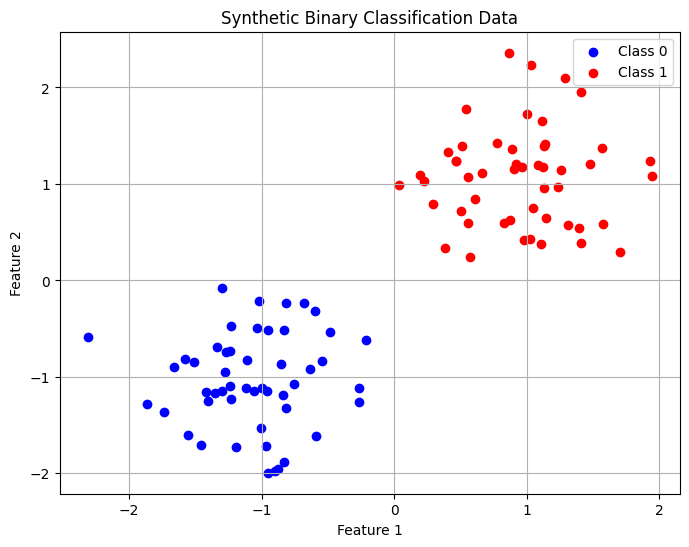

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- 1. Generate a Synthetic Dataset for Binary Classification ---
# We'll create a simple 2D dataset that is linearly separable for easier visualization.
np.random.seed(42)

# Class 0: bottom-left cluster
X_0 = np.random.randn(50, 2) * 0.5 + np.array([-1, -1])
y_0 = np.zeros((50, 1))

# Class 1: top-right cluster
X_1 = np.random.randn(50, 2) * 0.5 + np.array([1, 1])
y_1 = np.ones((50, 1))

X = np.vstack((X_0, X_1))
y = np.vstack((y_0, y_1))

# Shuffle the data
indices = np.arange(len(X))
np.random.shuffle(indices)
X = X[indices]
y = y[indices]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features (important for NN training stability)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"y_train shape: {y_train.shape}")

plt.figure(figsize=(8, 6))
plt.scatter(X[y.flatten() == 0, 0], X[y.flatten() == 0, 1], color='blue', label='Class 0')
plt.scatter(X[y.flatten() == 1, 0], X[y.flatten() == 1, 1], color='red', label='Class 1')
plt.title('Synthetic Binary Classification Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

### 2. Neural Network Implementation with Backpropagation

Here, we define a `NeuralNetwork` class that encapsulates the architecture (input, hidden, output layers), activation functions, forward pass, and the backpropagation algorithm for weight updates.

In [73]:
class NeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.1):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.learning_rate = learning_rate

        # Initialize weights and biases with small random values
        self.weights_input_hidden = np.random.randn(input_size, hidden_size) * 0.01
        self.bias_hidden = np.zeros((1, hidden_size))
        self.weights_hidden_output = np.random.randn(hidden_size, output_size) * 0.01
        self.bias_output = np.zeros((1, output_size))

    def sigmoid(self, x):
        # Clip values to prevent overflow in np.exp
        x = np.clip(x, -500, 500)
        return 1 / (1 + np.exp(-x))

    def sigmoid_derivative(self, x_sigmoid_output):
        return x_sigmoid_output * (1 - x_sigmoid_output)

    def forward(self, X):
        # Input to Hidden Layer
        self.hidden_input = np.dot(X, self.weights_input_hidden) + self.bias_hidden
        self.hidden_output = self.sigmoid(self.hidden_input)

        # Hidden to Output Layer
        self.output_input = np.dot(self.hidden_output, self.weights_hidden_output) + self.bias_output
        self.output = self.sigmoid(self.output_input) # Sigmoid for binary classification output
        return self.output

    def backward(self, X, y, output):
        # Calculate the error at the output layer (Binary Cross-Entropy derivative)
        # For BCE, dL/dy_pred = (y_pred - y_true) / (y_pred * (1 - y_pred))
        # And dy_pred/d_output_input = y_pred * (1 - y_pred)
        # So, dL/d_output_input = (y_pred - y_true)
        error_output = output - y

        # Gradients for output layer weights and biases
        d_weights_hidden_output = np.dot(self.hidden_output.T, error_output)
        d_bias_output = np.sum(error_output, axis=0, keepdims=True)

        # Propagate error to hidden layer
        error_hidden = np.dot(error_output, self.weights_hidden_output.T) * self.sigmoid_derivative(self.hidden_output)

        # Gradients for hidden layer weights and biases
        d_weights_input_hidden = np.dot(X.T, error_hidden)
        d_bias_hidden = np.sum(error_hidden, axis=0, keepdims=True)

        # Update weights and biases
        self.weights_hidden_output -= self.learning_rate * d_weights_hidden_output
        self.bias_output -= self.learning_rate * d_bias_output
        self.weights_input_hidden -= self.learning_rate * d_weights_input_hidden
        self.bias_hidden -= self.learning_rate * d_bias_hidden

    def train(self, X_train, y_train, epochs):
        losses = []
        for epoch in range(epochs):
            output = self.forward(X_train) # Forward pass

            # Calculate Binary Cross-Entropy loss
            # Add a small epsilon to avoid log(0)
            epsilon = 1e-10
            loss = -np.mean(y_train * np.log(output + epsilon) + (1 - y_train) * np.log(1 - output + epsilon))
            losses.append(loss)

            self.backward(X_train, y_train, output) # Backward pass and weight update

            if (epoch + 1) % 100 == 0 or epoch == 0:
                predictions = (output > 0.5).astype(int)
                accuracy = np.mean(predictions == y_train)
                print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}, Accuracy: {accuracy:.4f}")
        return losses

    def predict(self, X):
        probabilities = self.forward(X)
        return (probabilities > 0.5).astype(int)

### 3. Training and Evaluation

Now, let's initialize our neural network and train it using the synthetic dataset. We'll monitor the loss and accuracy during training and then visualize the results.


Training Neural Network from scratch...
Epoch 1/1000, Loss: 0.6932, Accuracy: 0.4625
Epoch 100/1000, Loss: 0.0551, Accuracy: 1.0000
Epoch 200/1000, Loss: 0.0156, Accuracy: 1.0000
Epoch 300/1000, Loss: 0.0086, Accuracy: 1.0000
Epoch 400/1000, Loss: 0.0059, Accuracy: 1.0000
Epoch 500/1000, Loss: 0.0044, Accuracy: 1.0000
Epoch 600/1000, Loss: 0.0035, Accuracy: 1.0000
Epoch 700/1000, Loss: 0.0029, Accuracy: 1.0000
Epoch 800/1000, Loss: 0.0025, Accuracy: 1.0000
Epoch 900/1000, Loss: 0.0022, Accuracy: 1.0000
Epoch 1000/1000, Loss: 0.0019, Accuracy: 1.0000

Test Accuracy: 1.0000


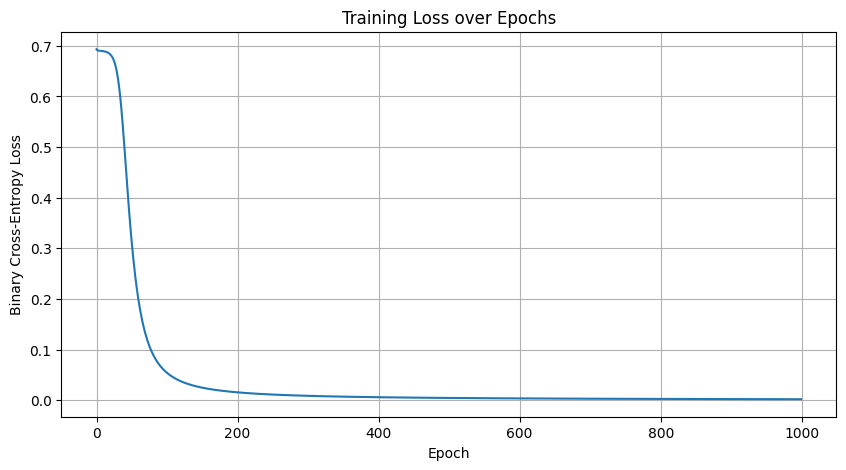

In [76]:
# --- 4. Initialize and Train the Network ---
input_size = X_train_scaled.shape[1] # Number of features (2 in this case)
hidden_size = 5 # Number of neurons in the hidden layer
output_size = 1 # Binary classification (1 output neuron)
learning_rate = 0.01 # Adjusted learning rate to a smaller value
epochs = 1000 # Number of training epochs

n_network = NeuralNetwork(input_size, hidden_size, output_size, learning_rate)

print("\nTraining Neural Network from scratch...")
training_losses = n_network.train(X_train_scaled, y_train, epochs)

# --- 5. Evaluate the model on the test set ---
predictions_test = n_network.predict(X_test_scaled)
accuracy_test = np.mean(predictions_test == y_test)
print(f"\nTest Accuracy: {accuracy_test:.4f}")

# --- 6. Visualize Training Loss ---
plt.figure(figsize=(10, 5))
plt.plot(training_losses)
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.grid(True)
plt.show()

### 4. Visualize the Decision Boundary

For 2D input data, we can visualize the decision boundary learned by our neural network. This shows how the network separates the two classes in the input space.

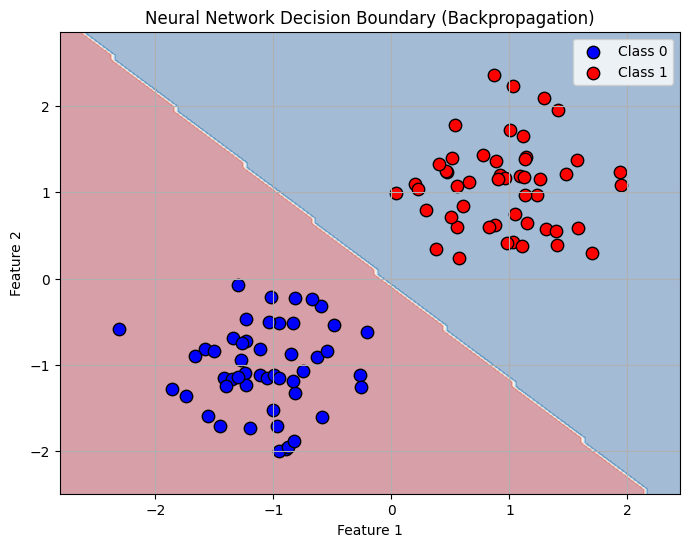

In [77]:
# --- 7. Visualize Decision Boundary ---
def plot_decision_boundary(model, X, y, scaler):
    plt.figure(figsize=(8, 6))

    # Create a meshgrid to plot the decision boundary
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    # Generate points in the meshgrid at original scale
    xx_orig, yy_orig = np.meshgrid(np.linspace(x_min, x_max, 100),
                                   np.linspace(y_min, y_max, 100))

    # Scale meshgrid points before feeding to the model
    Z_scaled = scaler.transform(np.c_[xx_orig.ravel(), yy_orig.ravel()])

    # Get predictions from the model (scaled input)
    Z = model.predict(Z_scaled)
    Z = Z.reshape(xx_orig.shape)

    # Plot the decision boundary
    plt.contourf(xx_orig, yy_orig, Z, alpha=0.4, cmap=plt.cm.RdBu)

    # Plot original data points
    plt.scatter(X[y.flatten() == 0, 0], X[y.flatten() == 0, 1], color='blue', label='Class 0', edgecolors='k', s=80)
    plt.scatter(X[y.flatten() == 1, 0], X[y.flatten() == 1, 1], color='red', label='Class 1', edgecolors='k', s=80)

    plt.title('Neural Network Decision Boundary (Backpropagation)')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_decision_boundary(n_network, X, y, scaler)

This implementation provides a foundational understanding of how ANNs learn through forward and backward passes. It demonstrates that even a simple network built from scratch can effectively learn to classify data.